# DeepDive 7: Pretraining a 1M Parameter Mini-BERT Architecture: Multi-Task Optimization and Structural Evaluation on Korean Corpus

### TABLE OF CONTENTS

1. [**Introduction**](#introduction)
2. [**Model Training**](#model-training)
3. [**Analysis**](#analysis)
4. [**Conclusion**](#conclusion)

## Introduction 

### **SECTION 1: INTRODUCTION & LLM PIPELINE OVERVIEW**

#### 1.1 Technical Overview of the 3-Stage LLM Training Pipeline

The development of modern Large Language Models (LLMs) follows a hierarchical, data-driven optimization trajectory. The process moves from general statistical distribution modeling to instruction alignment. This sequence is strictly non-reversible because each stage acts as a structural prerequisite for the next.



**STAGE 1: PRETRAINING (Self-Supervised Representation Learning)**

* **Target:** Learn raw grammar, factual knowledge, and universal bidirectional features.
* **Mechanics:** $\min_{\theta} \mathcal{L}_{\text{Joint}}(\theta)$ over unannotated text.



**STAGE 2: SUPERVISED FINE-TUNING (SFT) (Targeted Instruction Adaptation)**

* **Target:** Convert passive text completions into active, directive-following answers.
* **Mechanics:** Cross-Entropy loss minimized solely over response token bounds.



**STAGE 3: REINFORCEMENT LEARNING FROM HUMAN FEEDBACK (RLHF) (Value Alignment)**

* **Target:** Maximize human preference metrics regarding safety, utility, and helpfulness.
* **Mechanics:** Policy gradient tracking optimized via PPO or DPO algorithms.



#### 1.2. Step-by-Step Structural Decomposition of Training Stages

**STAGE 1: Pretraining (Foundation Representation Phase)**

* **Core Objective:** Model the probability distribution of text across a massive, unannotated corpus to learn grammar, syntax, semantics, and world facts.
* **Mathematical Framework:** Optimized via self-supervised proxy tasks. For instance, the joint optimization of BERT uses Masked Language Modeling ($\mathcal{L}_{\text{MLM}}$) and Next Sentence Prediction ($\mathcal{L}_{\text{NSP}}$):

$$ \mathcal{L}_{\text{Pretrain}}(\theta) = \mathcal{L}_{\text{MLM}}(\theta) + \mathcal{L}_{\text{NSP}}(\theta) $$


* **Evaluation Metrics:**
  * **Perplexity (PPL):** Measures exponential cross-entropy to track text predictability: $\text{PPL} = \exp(\mathcal{L}_{\text{CE}})$.
  * **Task-Specific Accuracy:** MLM accuracy over masked positions and binary classification accuracy for NSP.


* **Prerequisites:** Raw web-scale text corpora (e.g., Wikipedia, Common Crawl), subword tokenizers (e.g., SentencePiece, Byte-Pair Encoding), and high-throughput compute infrastructure.

 
**STAGE 2: Supervised Fine-Tuning (SFT) (Instruction Adaptation Phase)**

* **Core Objective:** Adapt the pretrained model to follow specific instructions and interact effectively with users via target `[Prompt-Response]` pairs.
* **Mathematical Framework:** Minimizes standard conditional Cross-Entropy loss. Crucially, gradients are calculated only over the target response tokens ($Y$), ignoring prompt tokens ($X$):

$$ \mathcal{L}_{\text{SFT}}(\theta) = -\sum_{t=1}^{|Y|} \log P_{\theta}(y_t \mid X, y_{<t}) $$


* **Evaluation Metrics:**
  * **ROUGE (1, 2, L):** Evaluates n-gram overlap and recall metrics against reference target texts.
  * **BLEU Score:** Assesses n-gram precision metrics for translation and generation stability.


* **Prerequisites:** High-quality, manually curated instruction-response data arrays.

**STAGE 3: RLHF / Alignment (Human Preference Phase)**

* **Core Objective:** Align outputs with human values, optimizing for helpfulness, accuracy, and safety while suppressing hallucinations or toxic generations.
* **Mathematical Framework:** Uses a reward model ($R_\phi$) trained on paired preference data ($y_w \succ y_l$). The policy ($\pi_\theta$) is optimized using Proximal Policy Optimization (PPO) or Direct Preference Optimization (DPO), balancing reward maximization with a KL-divergence penalty to stay close to the initial SFT policy ($\pi_{\text{SFT}}$):

$$ \max_{\theta} \mathbb{E}_{(x,y) \sim \pi_{\theta}} [R_{\phi}(x,y)] - \beta \, \mathbb{D}_{\text{KL}}(\pi_{\theta}(\cdot \mid x) \parallel \pi_{\text{SFT}}(\cdot \mid x)) $$


* **Evaluation Metrics:** Win-rate percentages on human evaluation benchmarks (e.g., LMSYS Chatbot Arena) and public safety/reasoning test suites (e.g., MMLU, GSM8K).
* **Prerequisites:** Human preference feedback datasets (Prompt, Chosen Response, Rejected Response).



### 1.3 System Architecture 

**A. The Rationale Behind the Pipeline Sequence**

The pipeline order cannot be altered because of the underlying mechanics of neural network convergence:

1. **Knowledge Acquisition First:** Pretraining builds the foundational parameter space, establishing semantic understanding and linguistic capacity. SFT datasets are too small to inject deep world knowledge; attempting SFT first leads to extreme overfitting.
2. **Formatting and Direction Second:** SFT maps the model's existing knowledge base onto an interactive template.
3. **Refinement Third:** Alignment algorithms (RLHF) modify the model's subtle style, tone, and safety constraints. Trying to apply RLHF without SFT causes reinforcement policies to diverge due to the high variance of the initial action space.



**B. Tokenization Strategy across Pipeline Stages**

A critical design question is whether tokenization must be rerun at each stage. While text must be converted to integers at every step, **the vocabulary array ($V$) itself must remain fixed across all stages.**

* **Fixed Vocabulary Constraint:** Modifying vocabulary boundaries after pretraining invalidates the dimension weights of the token embedding matrix ($E \in \mathbb{R}^{|V| \times d_{\text{model}}}$) and the final prediction layer.
* **Execution Rule:** The tokenization sub-routine is executed during every data preparation pipeline to transform text into integer matrices, but it must use the exact same tokenizer file trained during Stage 1.


**C. Comparative Analysis: Why Prior Projects Classified as SFT**

Prior implementations, such as **Naver Movie Sentiment Analysis** and **Workplace Harassment Dialogue Classification**, fall strictly under Stage 2 (Supervised Fine-Tuning) rather than Stage 1 (Pretraining).

| Technical Dimension | Prior Fine-Tuning Projects (SFT Case) | Current Pretraining Project (Stage 1 Case) |
| --- | --- | --- |
| **Objective Task** | Narrow Classification ($f: \mathbf{X} \to \mathbf{Y}_{\text{discrete}}$) | Masked Recovery and Sequence Prediction |
| **Data Nature** | Labeled Target Annotations (e.g., 0 for Negative, 1 for Positive) | Raw, Unannotated Korean Text Corpora |
| **Tokenizer Engine** | **Mecab** (Morphological Analyzer) | **SentencePiece** (BPE Subword Framework) |
| **Out-Of-Vocabulary (OOV) Handling** | Returns `[UNK]` for unseen words, dropping structural context | Decomposes unseen strings into character pieces |
| **Parameter Impact** | Task-specific layers adapt; the base representations remain stationary | The fundamental language representations are learned from scratch |


* **Mecab (Morphological/Dictionary-based):** Splitting text into fixed morphemes (nouns, particles, verbs) is highly effective for downstream classification tasks like sentiment analysis. However, its rigid dictionary structure cannot scale to pretraining, as it drops unknown or out-of-vocabulary words into `[UNK]` slots. This breaks the continuity required to model raw language distributions from scratch.
* **SentencePiece (BPE/Subword-based):** By learning subword pieces statistically from a corpus, it handles any text input without relying on a pre-defined dictionary. If it encounters a brand-new or misspelled word during pretraining, it cleanly breaks it down into small sub-character pieces ($t \in V$). This eliminates information loss and ensures robust, universal text representations.


### 1.4 Architectural Decomposition of Multi-stage Training

**A. Structural Suitability by Model Architecture**

Models do not inherently restrict themselves to a single training stage. Instead, their structural design dictates which phases are mathematically optimal.

```
                  +-----------------------+
                  | Model Architectures   |
                  +-----------------------+
                              |
              +---------------+---------------+
              |                               |
              v                               v
   +---------------------+         +---------------------+
   |    Encoder-Only     |         |    Decoder-Only     |
   |    (e.g., BERT)     |         |   (e.g., GPT, LLaMA)|
   +---------------------+         +---------------------+
              |                               |
      [Pretraining Only]            [Full 3-Stage Pipeline]
  - MLM Context Extraction        - Stage 1: Causal Pretraining
  - Downstream Task Feature Base  - Stage 2: Instruction SFT
                                  - Stage 3: Preference RLHF
```

**Encoder-Only Architectures (e.g., BERT, RoBERTa)**

* **Structural Profile:** 
  * Utilizes fully bidirectional self-attention matrices to compute dense representation fields over the entire sequence token grid simultaneously.
* **Stage 1: Pretraining Focus:** 
  * Highly optimized for Masked Language Modeling ($\mathcal{L}_{\text{MLM}}$). The bidirectional matrix allows the model to leverage both left-hand and right-hand structural context to fill textual gaps.
* **Downstream Fine-Tuning:** 
  * Because encoder-only models compute dense contextual vectors rather than autoregressively generating novel text streams, they **do not undergo typical conversational SFT or RLHF pipelines**. 
  * Instead, they are modified via downstream classification heads for narrow predictive execution tasks (e.g., Sentiment Analysis, Named Entity Recognition).

**Decoder-Only Architectures (e.g., GPT, LLaMA, Mistral)**

* **Structural Profile:** 
  * Enforces a strict causal attention mask (lower-triangular matrix) that restricts each token position from inspecting any forward-facing or future context.
* **The Full 3-Stage Pipeline Necessity:** 
  * Because their objective function is text generation via autoregressive Next-Token Prediction ($\arg\max P(x_t \mid x_{<t})$), these models **must execute the complete 3-stage training pipeline** to achieve commercial utility.




**B. Multi-Stage Operational Layout for Decoder-Only Generation Engines**

For autoregressive generation models, the multi-stage training framework operates sequentially over a single stationary architecture.

```
[Raw Text Corpus] ----> STAGE 1: Causal Pretraining ----> Base Foundation Model
                                                               |
[Prompt-Response] ----> STAGE 2: Supervised Fine-Tuning -> Instruct/Chat Model
                                                               |
[Human Preferences] --> STAGE 3: Preference Alignment ----> Aligned Production Model

```

**Step 1: Causal Pretraining (The Base Layer)**

* **Target Models:** GPT-Base, LLaMA-Base, Mistral-Base.
* **Operational Execution:** The model continuously shifts across vast string sequences, minimizing causal autoregressive cross-entropy loss:

$$ \mathcal{L}_{\text{Causal}}(\theta) = - \sum_{i=1}^{N} \log P_{\theta}(x_i \mid x_{<i}) $$


* **Output State:** Yields a **Base Foundation Model** (e.g., LLaMA-Base). It possesses exceptional world knowledge and syntax, but behaves like an advanced autocomplete system. It cannot hold a dialogue and will repeat prompts or continue web pages rather than answering questions.

**Step 2: Supervised Fine-Tuning (SFT) (The Interface Layer)**

* **Target Models:** GPT-Instruct, LLaMA-Chat, Mistral-Instruct.
* **Operational Execution:** The same structural model weights are updated using targeted `[Prompt-Response]` pairs. The optimization switches from unguided completion to localized, conversational answer formatting.
* **Output State:** Yields an **Instruct or Chat Model** (e.g., LLaMA-Instruct). The network learns when to start generating, how to format code, and when to conclude the response with an end-of-sequence token (`[EOS]`).

**Step 3: Reinforcement Learning from Human Feedback (RLHF) (The Safety & Preference Layer)**

* **Target Models:** Production-ready ChatGPT, Claude, LLaMA-Aligned.
* **Operational Execution:** The fine-tuned parameters undergo optimization via a reward model proxy. This phase calibrates subtle text attributes such as tone, structural alignment, and safety boundaries without altering foundational language mechanics.
* **Output State:** Yields an **Aligned Production Model**. This version refuses to output hazardous materials, addresses toxic text prompts gracefully, and aligns tightly with targeted human constraints.



Before a Bidirectional Encoder Representations from Transformers (BERT) architecture can be optimized, raw unstructured textual corpora must be converted into formatted, aligned, and masked numerical tensors. This report details the theoretical foundations and implementation blueprints of our data processing engine, which transforms raw Korean Wikipedia data (`kowiki.txt`) into high-performance, disk-backed binary matrices (`np.memmap`) ready for distributed neural network training.


### **SECTION 2: STRUCTURAL COMPARATIVE ANALYSIS: ENCODER EMBEDDING VS. CAUSAL DECODER PIPELINES**

### 2.1. Structural Comparison: Bidirectional Encoder(BERT) vs. Causal Decoder(GPT)

* The fundamental divergence between **BERT** and **GPT** lies in their self-attention masking mechanisms, which dictate their optimization objectives and downstream application profiles. 
* Both architectures utilize the Pretraining-then-Fine-Tuning paradigm, but they process text representations through contrasting geometric spaces.

| Technical Dimension | BERT (Bidirectional Encoder-Only) | GPT (Causal Decoder-Only) |
| --- | --- | --- |
| **Attention Matrix** | Fully Bidirectional (Unmasked) | Causal Masking (Lower-Triangular) |
| **Contextual Window** | Inspects both left and right tokens simultaneously ($x_{<t}$ and $x_{gt}$) | Restricted strictly to historical left-hand context ($x_{<t}$) |
| **Pretraining Objective** | Masked Language Modeling ($\mathcal{L}_{\text{MLM}}$) + NSP | Autoregressive Next-Token Prediction ($\mathcal{L}_{\text{Causal}}$) |
| **Primary Capabilities** | Feature Extraction, Dense Contextual Embedding | Open-Ended Natural Language Generation |
| **Downstream Stage 2** | Fine-Tuning via Task-Specific Classification Heads | Conversational Supervised Fine-Tuning (SFT) |
| **Downstream Stage 3** | Not Applicable (No autoregressive generation space) | Preference Alignment via RLHF / DPO Pipelines |


### 2.2. Data Pipeline Trajectory

#### **A. The BERT (Bidirectional Encoder) Trajectory**
```
[STAGE 1: PRETRAINING]
Input : Raw, unannotated text corpora (e.g., internet news articles, Wikipedia entries).
        -> No human-curated classifications or annotations are present.
        -> The data pipeline dynamically masks token indices (e.g., [MASK]), 
           synthetically establishing those original words as the internal target labels.
Output: A foundational language checkpoint mapping text tokens into dense contextual vectors 
        (e.g., 768-dimensional or 128-dimensional fields) via fully bidirectional attention.
                                    |
                                    v (Parameter Weight Initialization)
[STAGE 2: DOWNSTREAM FINE-TUNING] 
Input : [Stage 1 Pretrained Checkpoint Model] + [Human-Annotated Target Dataset]
        - Example A: "This movie is exceptionally entertaining." -> [Target Label: Positive (1)]
        - Example B: "Why can't you perform your duties correctly?" -> [Target Label: Harassment (1)]
Output: A highly specialized classification engine optimized for target domain deployment 
        (e.g., Naver Movie Review Sentiment Classifier or Workplace Aggression Detection Model).
```
**Discriminative Feature & Dense Mapping Paradigm**

*   The encoder architecture targets discriminative features and dense token mappings, moving sequentially from broad self-supervised structural representations to localized supervised classification tasks.
*   Instead of adapting via standard conversational pipelines, the model transfers parameters from data-rich foundational weights ($\theta_{\text{Base}}$) directly to task-specific downstream classifiers.

**[STAGE 1: SELF-SUPERVISED PRETRAINING (Foundational Representation)]**

*   **Input Data:** Web-scale, unannotated Korean text tokens ($\mathbf{X} \in \mathbb{R}^{B \times L}$) with no external human annotations.
*   **Label Self-Generation:** The engine initializes core representations strictly through Self-Supervised Learning (SSL). The data pipeline dynamically replaces internal text elements with a structural placeholder (`[MASK]`), extracting the original uncorrupted tokens as target labels ($\mathbf{Y}_{\text{MLM}}$) automatically.
*   **Core Output:** A foundational weight matrix parameter set ($\theta_{\text{Base}}$). This output maps input text into non-generative, high-dimensional contextual feature vectors ($h \in \mathbb{R}^{d_{\text{model}}}$) by scanning the entire bidirectional sequence window at once.
                    
                                
**[STAGE 2: DOWNSTREAM FINE-TUNING (Supervised Target Adaptation)]**

*   **Required New Data:** Yes. A smaller target corpus manually annotated by human experts with explicit categorical constraints ($\mathbf{Y}$).
    *   *Example (Sentiment Analysis):* $\mathbf{X} = \text{"text"}$, $\mathbf{Y} = \{0 \text{ (Negative)}, 1 \text{ (Positive)}\}$
    *   *Example (Harassment Detection):* $\mathbf{X} = \text{"dialogue"}$, $\mathbf{Y} = \{0 \text{ (Normal)}, 1 \text{ (Aggressive)}\}$
*   **Input Mechanics:** The system links a lightweight projection layer (e.g., `nn.Linear`) directly to the pretrained encoder backbone ($\theta_{\text{Base}}$) and injects the labeled downstream dataset to map context onto target categories.
*   **Final Output:** A highly specialized discriminative classification model optimized for narrow domain tasks (e.g., Naver Movie Review or Workplace Harassment classifiers).

**[ARCHITECTURAL BOUNDARY: DOES BERT UNDERGO RLHF?]**
*   **Absolute Refusal:** No. BERT cannot undergo Reinforcement Learning from Human Feedback (RLHF) because it structurally lacks an autoregressive token generation channel.
*   **Policy Constraints:** RLHF optimizes conversational generation by rewarding or penalizing open-ended text outputs word-by-word into the future based on human preference data.
*   **Generation Space Absence:** Because a bidirectional encoder pools an entire sequence into fixed vector spaces simultaneously rather than dynamically generating novel text streams, the mathematical framework of RLHF is completely inapplicable, and multi-response preference registries are unnecessary.


#### **B. The GPT / LLaMA (Causal Decoder-Only)Trajectory**

```
[STAGE 1: CAUSAL PRETRAINING]
Input : Web-scale, unannotated multi-domain text repositories.
        -> No explicit categorical tags are provided. The causal attention loss framework 
           automatically defines the immediate next token ($x_{t+1}$) as the target label 
           for the preceding sequence window ($x_{\le t}$).
        -> Example: Input sequence "The capital city of South Korea is" 
                    -> [Internal Target Label: "Seoul"]
Output: A Base Foundation Model (e.g., LLaMA-Base) functioning as a high-capacity statistical 
        autocomplete engine with broad semantic knowledge but no conversational formatting.
                                    |
                                    v (Parameter Weight Initialization)
[STAGE 2: SUPERVISED FINE-TUNING (SFT)]
Input : [Stage 1 Base Foundation Model] + [Human-Crafted Conversational Prompt-Response Pairs]
        - Input Prompt  : "User: Explain how to reverse a list in Python."
        - Response Label: "Assistant: You can reverse a list using the .reverse() method 
                           for in-place modification, or utilize slicing syntax [::-1]."
Output: An Instruct/Chat Model (e.g., LLaMA-Chat) capable of following system directives, 
        handling multi-turn dialogues, and cleanly halting generation via end-of-sequence [EOS] tokens.
                                    |
                                    v (Parameter Weight Initialization)
[STAGE 3: REINFORCEMENT LEARNING (RLHF / DPO)]
Input : [Stage 2 Chat Model] + [Human Preference Preference Registry Evaluation Triplets]
        - Input Prompt  : "Provide instructions on how to synthesize hazardous materials at home."
        - Chosen Label  : "I cannot fulfill this request. I am programmed to follow safety 
                           guidelines that restrict the dissemination of hazardous instructions."
        - Rejected Label: "To manufacture chemical compounds, you must first secure raw materials..."
Output: A commercial-grade Aligned Production Model (e.g., ChatGPT) optimized for utility, 
        factuality, and strict safety guidelines while preserving the fundamental language knowledge.
```

**Generative Distribution Modeling Paradigm**

*   The decoder architecture targets generative token distribution modeling, shifting from an unguided autoregressive autocomplete network to an aligned, conversation-ready agent.
*   To align open-ended generation behavior with strict user constraints, this trajectory requires completely different data configurations, token structures, and loss mechanics at each successive stage.
*   The common assumption that generative language models depend on human-annotated datasets holds true *only* starting from Stage 2 (Supervised Fine-Tuning). During initialization, the engine relies entirely on self-supervised data extraction.

**[STAGE 1: CAUSAL PRETRAINING (Autoregressive Base Phase)]**

*   **Input Mechanics:** Massive, web-scale unannotated multi-domain text repositories. There are no categorical tags, supervisor guidelines, or human labels present.
*   **Implicit Label Mapping:** Causal decoders process completely unannotated text streams by mapping future target vectors implicitly from historical contexts. The autoregressive loss logic automatically treats the very next token sequence element ($x_{t+1}$) as the target label for the preceding sequence window ($x_{\le t}$).
*   **Model Output:** A Base Foundation Model (e.g., LLaMA-Base). It functions strictly as a high-capacity statistical autocomplete module, predicting continuing text blocks based on probability without understanding dialogue structures, questions, or system instructions.
                         

**[STAGE 2: SUPERVISED FINE-TUNING (SFT / Conversational Adaptation)]**

*   **Input Mechanics:** The pretrained foundational base parameters paired with explicit, high-quality instruction datasets formatted as distinct, human-crafted prompt and response pairs:
    $$\mathcal{D}_{\text{SFT}} = \{(\text{Instruction}_i, \text{Target Response}_i)\}$$
*   **Format and Flow Control:** Gated Cross-Entropy loss calculates gradients exclusively over the response token boundaries. This trains the model to switch out of unguided sequence continuation and adopt an interactive assistant persona.
*   **Model Output:** An Instruct or Chat Model (e.g., LLaMA-Chat). The network learns to format its outputs conditionally based on template instructions and masters when to conclude text generation using structural end-of-sequence (`[EOS]`) tokens.
                    


**[STAGE 3: REINFORCEMENT LEARNING FROM HUMAN FEEDBACK (RLHF / Safety Alignment)]**
*   **Input Mechanics:** The conversational instruction-tuned checkpoint matched with a human preference alignment data registry. This registry contains a single input query mapped to multiple contrasting model responses evaluated by human annotators:
    $$\mathcal{D}_{\text{Alignment}} = \{(\text{Prompt}_i, \text{Chosen Response}_w, \text{Rejected Response}_l)\}$$
*   **Preference and Safety Optimization:** The network updates via reinforcement policy gradients (e.g., PPO or DPO), learning to maximize reward functions tied to human values, helpfulness, and factual accuracy while penalizing toxic or hazardous token outputs.
*   **Model Output:** A commercial-grade Production Model (e.g., ChatGPT). The alignment refines subtle stylistic preference boundaries and active safety parameters while fully preserving the foundational world knowledge base learned during Stage 1.

### **SECTION 3: BERT ARCHITECTURE & BIDIRECTIONAL ATTENTION MECHANICS**

BERT (Bidirectional Encoder Representations from Transformers) is architecturally defined as a deep, multi-layer bidirectional Transformer **encoder**. Unlike decoder-only architectures that restrict information flow via causal masks, BERT’s fundamental design principle is the total relaxation of directional constraints, allowing each hidden representation to attend to the entire input sequence simultaneously.

### 3.1. Architectural Topology: The Encoder Stack

The BERT model is composed of a vertical stack of $L$ identical Transformer blocks. Each block is characterized by a bipartite structure: a multi-head self-attention mechanism followed by a position-wise feed-forward network.

* **A. Embedding Layer ($E$):** The input representation is a concatenation of three distinct embedding vectors for each token $x_i$:
  * **Token Embedding:** Learned vector representing the subword semantic identity.
  * **Segment Embedding ($E_A, E_B$):** Binary indicators distinguishing between sentence pairs in the NSP task.
  * **Position Embedding ($P$):** Absolute learned positional vectors (unlike sinusoidal encodings) required to inject structural ordering into the permutation-invariant self-attention mechanism.
  * *Mathematical Definition:* $h_0 = \text{Token}_i + \text{Segment}_i + \text{Pos}_i$


* **B. Multi-Head Self-Attention (MHSA):** This is the core mechanism enabling bidirectional context. For a given hidden state sequence $H \in \mathbb{R}^{N \times d}$, MHSA computes projections into Queries ($Q$), Keys ($K$), and Values ($V$):
  * $Q = HW_Q, \quad K = HW_K, \quad V = HW_V$
  * The attention function is defined as:

  $$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$


  * **Bidirectional Meaning:** Because there is no causal mask (no look-ahead restriction), the matrix $QK^T$ captures the correlation between token $i$ and token $j$ regardless of their relative positions. $Q_i$ acts as a "requester" of context, $K_j$ acts as a "descriptor" of available context, and the dot product calculates the strength of this interaction.


* **C. Feed-Forward Networks (FFN):** Each layer contains two linear transformations with a non-linear activation (typically GELU) in between:

$$\text{FFN}(x) = \text{GELU}(xW_1 + b_1)W_2 + b_2$$



This layer projects the attention-aggregated features into a higher-dimensional space and back, allowing the model to learn complex, non-linear compositions of the features highlighted by the attention mechanism.
* **D. Residual Connections & Layer Normalization:** Each sub-layer utilizes an add-and-norm operation:

$$\text{LayerNorm}(x + \text{Sublayer}(x))$$



These connections are vital to prevent vanishing gradients in deep stacks, ensuring the gradient signals can propagate back to early layers during backpropagation.



### 3.2. The Nature of Bidirectional Attention

In a causal model, the attention matrix is strictly lower triangular ($A_{ij} = 0$ for $i < j$). In BERT, the attention matrix is **dense and full**.

* **Global Contextualization:** By allowing $x_i$ to attend to both $x_{i-n}$ and $x_{i+n}$, BERT constructs a representation where the meaning of a word is functionally dependent on its entire surrounding syntactic and semantic environment.
* **Vector Space Transformation:** Across $L$ layers, the latent space undergoes iterative refinement. Lower layers primarily extract local, syntactic dependencies (e.g., noun-adjective agreement), while higher layers aggregate global semantic concepts required for tasks like NSP.


#### **Core Parameters**

| Component | Function | Mathematical Impact |
| --- | --- | --- |
| **$W_Q, W_K, W_V$** | Learnable projection matrices | Maps input to subspace for context matching |
| **$\text{softmax}(\frac{QK^T}{\sqrt{d_k}})$** | Scaled dot-product attention | Computes the relevance score (weight) |
| **$V$** | Value projection | The information content to be aggregated |
| **Residual Path** | Bypass connections | Prevents information loss across $L$ layers |

In essence, BERT transforms the input from a sequence of discrete tokens into a high-dimensional contextual manifold where the final representation of any token is a weighted sum of all other tokens, filtered through the specific learned attention weights $A_{ij} = \text{softmax}(\frac{Q_i K_j^T}{\sqrt{d_k}})$. This transformation is the engine behind BERT's superior performance in capturing complex, non-local linguistic relationships.



### 3.3 Theoretical Framework & Dual-objective Optimization 

#### **A. Data Processing Pipeline: From Raw Corpus to Tensors**

The pretraining pipeline transforms unstructured text into optimized numerical representations through a series of structural stages:

```
[Raw Corpus] ──► [Document Parsing & Sentence Split] ──► [NSP Construction: 50/50 IsNext/NotNext]
                                                                     │
                                                                     V
[Numerical Tensors (memmap)] ◄── [MLM 80-10-10 Cloaking] ◄── [Tokenization & ID Mapping]

```

* **Document Parsing:** Sequential text is organized into coherent sentence pairs to facilitate document-level relationship learning.
* **NSP Frame Construction:** To train the model in sequence coherence, $50\%$ of the data pairs are ground-truth consecutive sentences, while the remaining $50\%$ are randomly paired from disparate documents.
* **Tokenization & ID Mapping:** Raw strings are converted into discrete token IDs via SentencePiece or WordPiece, constrained by a fixed sequence length ($N=128$ or $512$).
* **MLM Cloaking:** Within the token stream, $15\%$ of positions are selected for masking; these are then processed via the **80-10-10 rule** to create the input tensor $\tilde{X}$.


#### **B. Objective A: Next Sentence Prediction (NSP)**

NSP is a sequence-level discriminative task focused on modeling inter-sentence dependencies. It treats the `[CLS]` token as a global semantic aggregator.

* **Objective:** Model the conditional probability $P(Y \mid S_A, S_B)$, where $Y \in \{0, 1\}$.
* **Mathematical Logic:**

$$Y = \begin{cases} 1 & \text{if } S_B \text{ is the actual consecutive continuation of } S_A \\ 0 & \text{if } S_B \text{ is a randomly sampled span} \end{cases}$$


* **Structural Significance:** This task forces the `[CLS]` token to synthesize the global meaning of both segments, which is essential for downstream tasks like Question Answering (QA) and Natural Language Inference (NLI).


#### **C. Objective B: Masked Language Modeling (MLM)**

MLM serves as a token-level generative task. To enable bidirectional reasoning, it "cloaks" information to prevent the model from trivializing the task by simply looking at the target token in the input.

* **Objective:** Recover the original token $x_m$ from the corrupted sequence $\tilde{X}$, optimized via cross-entropy loss:$$\mathcal{L}_{\text{MLM}}(\theta) = -\sum_{m \in M} \log P(x_m \mid \tilde{X}; \theta)$$
  * **The 80-10-10 Cloaking Strategy:** To bridge the "pretraining-finetuning gap" (since `[MASK]` tokens never appear during real-world inference), the $15\%$ masked subset is mutated as follows:
  * **$80\%$ (Fixed MASK):** Tokens are replaced by the special `[MASK]` token. This forces the model to rely entirely on bidirectional context.
  * **$10\%$ (Random Swap):** Tokens are replaced by a uniform random sample $v_{\text{rand}} \sim \mathcal{U}(7, |V|-1)$. This acts as a regularizer, preventing the model from over-trusting the `[MASK]` token as a signal.
  * **$10\%$ (Identity):** Tokens remain unchanged. This forces the model to maintain high-quality representations even when no visual "cue" (like a` mask) exists.




#### **D. Structural Summary: Why This Matters**

* **Global vs. Local:** NSP captures **Global Coherence** (how sentences relate), while MLM captures **Local Semantics** (how words define each other).
* **Bidirectional Integrity:** By cloaking $15\%$ of the tokens, BERT forces the self-attention mechanism to learn a functional mapping from the *entire* sequence to specific positions, rather than just from "left-to-right" history.
* **Representation Manifold:** The final output of this framework is a deep contextual representation where token identity is defined not by dictionary definitions, but by the learned probability distribution of its neighbors.


### 3.4. The QKV Transformation: A Dynamic Re-projection

Within each Encoder layer, the input hidden representation $H$ (a matrix of tokens) is passed through three separate linear projection layers. These are essentially learned "filters":

Think of the input sequence $H$ (the hidden states from the previous layer) as a **database**.

* **$Q$ (Query):** Represents the **current token** (the one "asking" for context). If you are looking at the word "Apple," $Q_{\text{apple}}$ is the specific vector asking: *"Who or what is related to me in this sentence?"*
* **$K$ (Key):** Represents **every token in the sequence**, including the current one. Each token $j$ provides $K_j$ as a label: *"I am a subject," "I am a verb," "I am a location."*
* **$V$ (Value):** Represents the **content/information** of every token.

**The process is not "finding the answer" ($V$ is not a "ground truth" target).** Instead, $V$ is the raw information that the model decides is relevant to the Query.

#### **A. Why this is "Internal" to the Encoder**

The Encoder layer is a **closed system**. The sequence of operations is as follows:

1. **Input:** The Encoder receives $H_{in}$ from the previous layer.
2. **Transformation:** It projects $H_{in}$ into $Q$, $K$, and $V$.
3. **Interaction:** It computes the attention scores via the dot-product $\text{softmax}(\frac{QK^T}{\sqrt{d_k}})$. **This step is where the bidirectional nature happens:** every Query from token $i$ is compared to every Key from token $j$.
4. **Aggregation:** It multiplies these scores by $V$ to create a new, context-aware representation.
5. **Refinement:** The result is passed through the Feed-Forward Network and added back to the original input (Residual Connection).

#### **B. What "Happening within the Encoder" actually means**

When we say "QKV happens inside the encoder," it means:

* **Non-Stop Contextualization:** At Layer 1, the model learns simple relationships (e.g., "The" goes with "Cat"). By Layer 4, the QKV projections have been trained to filter for much more abstract concepts (e.g., "This noun is the subject of the sentence").
* **Dynamic Attention:** The QKV matrices ($W_Q, W_K, W_V$) are **learned parameters**. Through the MLM and NSP training objectives, the model learns *exactly* what Queries should match with what Keys.
* **Layer-wise Evolution:** Each layer in your BERT encoder has its own unique $W_Q, W_K, W_V$ parameters. This means Layer 1 performs one kind of filtering, while Layer 4 performs an entirely different, higher-level filtering.


#### **C. The Encoder (the "brain" that processes information) vs. The Task Head (the "mouth" that speaks the answer)**

* **The Encoder (Uses QKV):** This is the main body of BERT. Every time a sentence (whether it's for MLM or NSP) passes through the Encoder layers, it **must** use QKV self-attention to understand the relationships between words. Without QKV, the model wouldn't understand the sentence at all.
* **The Task Head (Does NOT use QKV):** Once the Encoder finishes processing the sentence and produces the final hidden vectors, these vectors are passed to a "Task Head" (a simple linear layer).
  * **MLM Head:** A linear layer that maps the hidden vector to vocabulary size ($V$).
  * **NSP Head:** A linear layer that maps the `[CLS]` token's hidden vector to a binary class (0 or 1).

#### **D. Two training objectives of the Encoder's QKV mechanism**


> **Summary of the Flow**
>* **QKV (Self-Attention):** The "Reading" phase. The model reads the input and calculates how words relate to each other. This is mandatory for *all* tasks.
> * **Task Heads (MLM or NSP):** The "Answering" phase.
>   * If you are doing **MLM**, you look at the QKV-processed vectors at specific masked positions.
>   * If you are doing **NSP**, you look at the QKV-processed vector at the `[CLS]` position.

#### 1. MLM (Masked Language Modeling) Task Flow

In MLM, the model must reconstruct specific, missing information. The QKV mechanism is utilized here as a **local-to-global information recovery tool**.

* **The Reading Phase (QKV):** Every token in the sequence (even the `[MASK]` tokens) generates Query, Key, and Value vectors. Through self-attention, the `[MASK]` token acts as a "Query," specifically asking its neighbors for the information it is missing.
* **The Aggregation Phase (Encoder Output):** The Encoder uses QKV to "pool" the surrounding context. By the time the hidden state at the masked position reaches the final layer, it has essentially performed a weighted aggregation of the surrounding tokens that provide the strongest clues to its identity.
* **The MLM Head:** Only the hidden vectors **at the specific masked positions** are passed to the MLM Head (a linear projection to vocabulary size). The MLM Head asks: *"Based on this context-rich vector created by QKV, which vocabulary token does it represent?"*

#### 2. NSP (Next Sentence Prediction) Task Flow

In NSP, the model must understand the global coherence of the sequence. The QKV mechanism is utilized here as a **global dependency synthesizer**.

* **The Reading Phase (QKV):** Throughout all layers of the Encoder, the `[CLS]` token participates in the QKV mechanism just like any other word. However, because it is designed to be the global representative, it "attends" to every token in both Sentence A and Sentence B across all layers.
* **The Aggregation Phase (Encoder Output):** Through the iterative QKV interactions, the `[CLS]` token's vector gradually absorbs the "meaning" of Sentence A and the "logical flow" of Sentence B. By the end of the Encoder, the `[CLS]` vector is no longer just a structural token; it is a mathematical summary of the sequence's coherence.
* **The NSP Head:** Only the hidden vector **at the `[CLS]` position** is passed to the NSP Head. The NSP Head asks: *"Based on this summary vector created by QKV, is the relationship between Sentence A and Sentence B coherent?"*


**QKV Utility**

| Feature | MLM Utilization | NSP Utilization |
| --- | --- | --- |
| **Primary Goal** | Reconstructing local missing details. | Assessing global sequence coherence. |
| **QKV Role** | Facilitates "Contextual Filling" for specific slots. | Facilitates "Contextual Summarization" for the whole. |
| **Target Hidden Vector** | Only vectors at `[MASK]` positions. | Only the vector at the `[CLS]` position. |
| **Dependency** | High reliance on immediate neighbors. | High reliance on long-range inter-sentence links. |

> **In summary:** The QKV mechanism is the same for both—it is a general-purpose attention engine. The difference is **which task head consumes the output**. MLM consumes local, word-specific hidden states to guess tokens, while NSP consumes a global, sentence-specific hidden state to guess relationship logic.



#### **E.How the QKV mechanism behaves differently for MLM and NSP**
#### 1. The Encoder's Role: The Context Engine (Common to both)

Regardless of the task, the Encoder treats the input as a bidirectional stream. Here is how $Q, K,$ and $V$ behave internally for **every** token:

* **Query ($Q_i$):** Represents the "focus" of token $i$. It identifies what information is missing for this token to be fully understood in its current context.
* **Key ($K_j$):** Represents the "identity/features" of token $j$. It helps the model decide if token $j$ is relevant to token $i$.
* **Value ($V_j$):** Represents the "content" of token $j$. If token $i$ finds token $j$ relevant (via high $Q_i \cdot K_j$ similarity), it absorbs $V_j$.


#### 2. MLM Task: Localized Reconstruction

In MLM, the "Answer" is hidden within the sequence itself. The QKV mechanism acts as a **feature recovery tool**.

* **Query ($Q_{\text{mask}}$):** The Query vector at the `[MASK]` position is specifically trained to "search" for semantic or syntactic clues in the surrounding words (e.g., "I am looking for a verb that matches this subject").
* **Key ($K_j$):** The surrounding tokens provide Keys that match the Query's search criteria (e.g., "I am the subject," "I am the tense marker").
* **Value ($V_j$):** The masked token absorbs the Value vectors of these relevant neighbors.
* **Result:** After the Encoder passes the information through these layers, the final hidden state at the `[MASK]` position is a **weighted sum of neighbor information** (the Value vectors) that points directly to the ground truth token ID.



#### 3. NSP Task: Global Coherence Assessment

In NSP, the "Answer" is the relationship between the two segments. The QKV mechanism acts as a **summary synthesizer**.

* **Query ($Q_{\text{CLS}}$):** The Query vector at the `[CLS]` token acts as the "Global Listener." It is trained to ask: *"What are the key elements of both Sentence A and Sentence B that establish a logical flow?"*
* **Key ($K_j$):** Every token in both sentences provides a Key that informs the `[CLS]` token about its role in the narrative (e.g., "I am a topic word in Sentence A," "I am a consequence in Sentence B").
* **Value ($V_j$):** The `[CLS]` token absorbs the Value vectors of tokens that provide evidence for sequence coherence.
* **Result:** By the final layer, the `[CLS]` vector is not a word; it is a **compressed summary of the entire context**. The Value vectors it has aggregated provide the evidence needed by the NSP head to decide if the sentences are sequential (Class 1) or random (Class 0).


#### Comparison Summary: Task-Specific Behavior

| Role | MLM (Masked Token) | NSP ([CLS] Token) |
| --- | --- | --- |
| **Q Focus** | "What word fits this specific gap?" | "Does this whole sequence make sense?" |
| **K Retrieval** | Searches for syntax and local meaning. | Searches for discourse markers and global logic. |
| **V Aggregation** | Collects data to reconstruct the word. | Collects evidence to verify the link. |
| **Input Source** | Primarily neighbors (Local context). | Entire input sequence (Global context). |

#### Mathematical Perspective

In both cases, the final representation is a **linear combination** of the Values:

$$h_{\text{final}} = \sum_{j=1}^{N} \text{softmax}\left(\frac{Q_{\text{target}} K_j^T}{\sqrt{d_k}}\right) V_j$$

* **For MLM:** $Q_{\text{target}}$ is the `[MASK]` vector. $h_{\text{final}}$ is the "reconstructed" token representation.
* **For NSP:** $Q_{\text{target}}$ is the `[CLS]` vector. $h_{\text{final}}$ is the "coherence score" foundation.

The Encoder does not "know" which task it is performing; it simply performs this linear combination over and over. It is the **gradient descent process** during training that forces the matrices $W_Q, W_K, W_V$ to evolve such that they become efficient at providing the right "data" to the MLM or NSP task heads.

### **SECTION 4: ENGINEERING IMPLEMENTATION DETAILS

#### Step 4-1: Document Boundary Extraction & Caching

Raw wiki streams contain arbitrary sentence distributions separated by double-newline symbols denoting structural boundaries.

* To prevent negative sample corruption during NSP operations, segments are grouped into isolated lists representing complete standalone documents.
* To minimize redundant compute over consecutive sessions, the finalized subword-encoded structure is compiled onto disk as a serialized binary cache utilizing `pickle` with `protocol=HIGHEST_PROTOCOL`. This drops initialization latency from several hours down to **0.1 seconds** on standard local CPU architectures.

#### Step 4-2: Segment Trimming & Whole-Word Masking (WWM)

Standard token-level masking splits morphological clusters destructively (e.g., masking only a single subword within a single target verb block, which makes the recovery task trivial). Our algorithm enforces a strict cluster boundary routine:

1. **Phrase Clustering:** Evaluates token markers generated by our 8,000-vocabulary SentencePiece model. Subwords missing the Unicode space indicator prefix (`u"\u2581"`) are dynamically appended to the preceding active index array, constructing single independent word blocks:

$$\text{Word}_k = [i_{\text{start}}, \dots, i_{\text{end}}]$$


2. **Dynamic Range Trimming:** Sequences surpassing the sequence budget ($L_{\text{max}} = 128$) are balanced using an iterative length reduction loop:

$$\text{while } |S_A| + |S_B| > (L_{\text{max}} - 3): \text{ drop } \begin{cases} S_A[0] & \text{if } |S_A| > |S_B| \\ S_B[-1] & \text{otherwise} \end{cases}$$


3. **Dual Segment Grid Generation:** Produces binary masks identifying structural zones:

$$\text{Segment IDs} = [\underbrace{0, \dots, 0}_{|S_A|+2}, \underbrace{1, \dots, 1}_{|S_B|+1}]$$



#### Step 4-3: Memory-Mapped Matrix Layout Optimization

To bypass standard host RAM constraints during large-scale model optimization, Python's runtime allocations are converted directly into unbuffered native disk maps (`np.memmap`).

```
┌────────────────────────────────────────────────────────────────────────┐
│                      Final Pretraining Matrix Layout                   │
├─────────────┬──────────────────────────────────────────────────────────┤
│ input_ids   │ [CLS]  Token_A  [SEP]  Token_B  [SEP]  [PAD]  ...  [PAD] │ (Shape: [N, 128])
├─────────────┼──────────────────────────────────────────────────────────┤
│ segment_ids │   0       0       0       1       1      0    ...    0   │ (Shape: [N, 128])
├─────────────┼──────────────────────────────────────────────────────────┤
│ labels_mlm  │   0     Orig_ID   0       0    Orig_ID   0    ...    0   │ (Shape: [N, 128])
├─────────────┼──────────────────────────────────────────────────────────┤
│ labels_nsp  │ Binary Label Flag (1 = Consecutive True, 0 = Random Swap)│ (Shape: [N])
└─────────────┴──────────────────────────────────────────────────────────┘

In [ ]:
# ===========================================================================
# Global Imports & Configuration
# ===========================================================================
# 1. Essential Libraries 
import os, copy, time, glob, urllib.request, zipfile, json, math
import numpy as np
import random
from tqdm import tqdm
import pandas as pd 
import matplotlib.pyplot as plt
import nltk
import gensim
import koreanize_matplotlib

import torch, torchsummary
import torch.nn as nn
import torch.nn.functional as F
# -------------------------------------------------------------------------
# STEP 1: Device Configuration (Optimized for Apple Silicon)
# -------------------------------------------------------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(">>> Using Apple Silicon (MPS) for acceleration.")
else:
    device = torch.device("cpu")
    print(">>> Using CPU.")

>>> Using Apple Silicon (MPS) for acceleration.


In [2]:
# -------------------------------------------------------------------------
# STEP 2: Dataset Download & Cleaning
# -------------------------------------------------------------------------
# Dataset Download
# -------------------------------------------------------------------------
data_dir = "./data"
zip_path = os.path.join(data_dir, "kowiki.txt.zip")
target_file_path = os.path.join(data_dir, "kowiki.txt")

# Create directory if it lacks
os.makedirs(data_dir, exist_ok=True)

# Download and unzip only if the final text file does not exist
if os.path.exists(target_file_path):
    print("File already exists. Skipping download.")
else:
    if not os.path.exists(zip_path):
        print("Downloading zip file...")
        url = "https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip"
        os.system(f"wget -P {data_dir} {url}")

    print("Extracting zip file...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

    os.remove(zip_path)
    print("Extraction done and zip file removed.")

# Load and print sample lines from the dataset
print("\n--- Displaying Sample Lines ---")
with open(target_file_path, "r", encoding="utf-8") as f:
    for i in range(5):
        line = f.readline()
        if not line:
            break
        # Print each line after stripping trailing newlines
        print(f"Line {i+1}: {line.strip()}")
    print(f"[*] Removed the temporary zip file: {zip_path}")

File already exists. Skipping download.

--- Displaying Sample Lines ---
Line 1: 지미 카터
Line 2: 제임스 얼 "지미" 카터 주니어(, 1924년 10월 1일 ~ )는 민주당 출신 미국 39번째 대통령 (1977년 ~ 1981년)이다.
Line 3: 지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.
Line 4: 1962년 조지아 주 상원 의원 선거에서 낙선하나 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주 지사 선거에 낙선하지만 1970년 조지아 주 지사를 역임했다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.
Line 5: 1976년 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워, 포드를 누르고 당선되었다.
[*] Removed the temporary zip file: ./data/kowiki.txt.zip


In [8]:
# -------------------------------------------------------------------------
# STEP 3: Data Preprocessing: Tokenization 
# -------------------------------------------------------------------------
#  Train SentencePiece Tokenizer with 8k Vocab Size
# -------------------------------------------------------------------------
import sentencepiece as spm
# -------------------------------------------------------------------------
# Concept: SentencePiece relies purely on Data Statistics, NOT Human Dictionaries
# -------------------------------------------------------------------------
# 1. Subword merging is determined strictly by token frequency within the training corpus (Kowiki).
# 2. High-frequency clusters like "이것은" merge into a single token due to their heavy statistical presence.
# 3. Rare or literary phrases like "추적추적" remain split into granular characters because they lack sufficient frequency to be merged.
# 4. Segment IDs will ALWAYS match the final statistical pieces produced by the tokenizer.
data_dir = "data"
prefix = os.path.join(data_dir, "ko_8000")
model_path = f"{prefix}.model"

# Load the tokenizer directly if the trained model file already exists
if os.path.exists(model_path):
    print(f"[+] Found existing model at '{model_path}'. Loading directly...")
    vocab = spm.SentencePieceProcessor()
    vocab.load(model_path)
    print("Successfully loaded the 8k vocab tokenizer.")
else:
    # This block only triggers if you haven't trained the model yet
    print(f"[-] '{model_path}' not found. You need to run the trainer code first.")

# -------------------------------------------------------------------------
# Case 1: Tokenizer Functional Verification
# -------------------------------------------------------------------------
# Purpose: Ensures the SentencePiece processor is successfully loaded and
# can break a standard multilingual sentence down into subwords and numerical IDs.
# No BERT-specific sequence layout logic is applied here.
# -------------------------------------------------------------------------

sample_text = "이것은 mini BERT 모델을 위한 토크나이저 테스트 문장입니다."
tokens = vocab.encode_as_pieces(sample_text)
token_ids = vocab.encode_as_ids(sample_text)

print("\n--- Tokenizer Test Result ---")
print(f"Input Text: {sample_text}")
print(f"Output Tokens: {tokens}")
print(f"Output Token IDs: {token_ids}")

print("\n--- Special Token ID Check ---")
print(f"[PAD]  ID: {vocab.piece_to_id('[PAD]')}")
print(f"[UNK]  ID: {vocab.piece_to_id('[UNK]')}")
print(f"[SEP]  ID: {vocab.piece_to_id('[SEP]')}")
print(f"[CLS]  ID: {vocab.piece_to_id('[CLS]')}")
print(f"[MASK] ID: {vocab.piece_to_id('[MASK]')}")

[+] Found existing model at 'data/ko_8000.model'. Loading directly...
Successfully loaded the 8k vocab tokenizer.

--- Tokenizer Test Result ---
Input Text: 이것은 mini BERT 모델을 위한 토크나이저 테스트 문장입니다.
Output Tokens: ['▁이것은', '▁m', 'in', 'i', '▁B', 'E', 'R', 'T', '▁모델', '을', '▁위한', '▁토', '크', '나이', '저', '▁테', '스트', '▁문', '장', '입', '니다', '.']
Output Token IDs: [1488, 1195, 235, 3693, 395, 3899, 3924, 3839, 1238, 3607, 522, 363, 3753, 1967, 3872, 544, 216, 117, 3651, 3809, 1202, 3599]

--- Special Token ID Check ---
[PAD]  ID: 0
[UNK]  ID: 1
[SEP]  ID: 4
[CLS]  ID: 5
[MASK] ID: 6


In [ ]:
# -------------------------------------------------------------------------
# STEP 3: Data Preprocessing: Tokenization (Continued)
# -------------------------------------------------------------------------
# Q. Let's inspect tokens excluding the first 7 special/control tokens
vocab_list = []
for id in range(7, len(vocab)):
    # Append the subword piece if it is a valid token in the dictionary
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))

print(f"Total vocabulary size (excluding special tokens): {len(vocab_list)}")
print("Sample pieces from vocabulary:", vocab_list[:10])

# -------------------------------------------------------------------------
# Case 2: BERT-Formatted Sequence Construction
# -------------------------------------------------------------------------
# Step A: Assemble the Structural Frame (NSP & Segment Alignment)
# -------------------------------------------------------------------------
# Purpose: Demonstrates how to manually stitch two independent sentences
# into a unified layout ([CLS] + Sent A + [SEP] + Sent B + [SEP]) required
# for simultaneous Next Sentence Prediction (NSP) and Masked LM (MLM) training.
# -------------------------------------------------------------------------
# Define two raw sample sentences from a famous Korean novel ("Lucky Day")
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"

# -------------------------------------------------------------------------
# Construct a standard BERT input sequence format manually: [CLS] + Tokens A + [SEP] + Tokens B + [SEP]
# -------------------------------------------------------------------------
# Explanation of Key BERT Special Tokens
# -------------------------------------------------------------------------
# [CLS]: "Classification" token. Positioned at index 0 of every sequence. 
#        Its final hidden state serves as the aggregate sequence representation 
#        for classification tasks (like NSP or sentiment analysis).
#
# [SEP]: "Separator" token. Acts as a structural boundary marker.
#        It splits two distinct sentences apart and closes the entire sequence.
#
# [MASK]: "Masking" token. Replaces a target subword (80% of the selected 15%).
#         Forces the model to predict the missing token using contextual cues.
# -------------------------------------------------------------------------
# Note on the remaining 4 tokens:
# [PAD] is used for equalizing batch lengths, [UNK] catches out-of-vocabulary characters,
# and [BOS]/[EOS] are standard SentencePiece delimiters not actively utilized by BERT.
# -------------------------------------------------------------------------
tokens_org = (
    ["[CLS]"]       # classification 
    + vocab.encode_as_pieces(string_a)
    + ["[SEP]"]     # a Segment ID of 0. This tells the self-attention layer: "This separator belongs to the first block of text."
    + vocab.encode_as_pieces(string_b)
    + ["[SEP]"]     # a Segment ID of 1. This tells the self-attention layer: "This separator belongs to the second block of text, meaning the entire sequence is complete."
)
# -------------------------------------------------------------------------
# Key Concept: Segment IDs align with Subword Tokens, NOT Syllables/Characters!
# -------------------------------------------------------------------------
# SentencePiece group frequent character clusters into single tokens (e.g., "이것은" -> 1 token).
# Therefore, the length of the Segment ID array must exactly match the number of
# tokenized subwords in the final sequence, regardless of how many characters are inside.

print("\n--- BERT Subword Tokenization Example ---")
print(f"Original Sequence Layout: [CLS], tokens a, [SEP], tokens b, [SEP]")
print(f"Tokens Sequence:\n{tokens_org}")

Total vocabulary size (excluding special tokens): 8000
Sample pieces from vocabulary: ['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다']

--- BERT Subword Tokenization Example ---
Original Sequence Layout: [CLS], tokens a, [SEP], tokens b, [SEP]
Tokens Sequence:
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']


In [5]:
# -------------------------------------------------------------------------
# STEP 4: Data Preprocessing: Masked Language Model (MLM) Generation
# -------------------------------------------------------------------------
def create_masked_lm_predictions(
    tokens, mask_prob=0.15, rng=random.Random(42)
):
    """Creates masked language modeling (MLM) predictions for a sequence of tokens
    based on the standard 80-10-10 BERT masking rule.
    """
    # Define a set of special tokens that must NEVER be masked during pretraining
    special_tokens = {"[CLS]", "[SEP]", "[PAD]", "[BOS]", "[EOS]", "[UNK]"}

    # Step 1: Identify all valid candidate indices for masking (excluding special tokens)
    candidate_indices = []
    for i, token in enumerate(tokens):
        if token not in special_tokens:
            candidate_indices.append(i)

    # Shuffle candidates to randomly select tokens for masking
    rng.shuffle(candidate_indices)

    # Step 2: Calculate the exact number of tokens to mask (15% of all candidate tokens)
    num_to_mask = max(1, int(round(len(candidate_indices) * mask_prob)))

    # Track selected positions and their corresponding original labels
    masked_lm_positions = []
    masked_lm_labels = []

    # Create a copy of the original sequence to safely apply mutations inline
    masked_tokens = list(tokens)

    # Sort the chosen indices to process them in chronological order
    chosen_indices = sorted(candidate_indices[:num_to_mask])

    # Step 3: Apply the 80-10-10 masking strategy to each selected token
    for index in chosen_indices:
        masked_lm_positions.append(index)
        masked_lm_labels.append(tokens[index])

        prob = rng.random()

        if prob < 0.80:
            # 80% of the time: Replace the token with the dedicated [MASK] token
            masked_tokens[index] = "[MASK]"

        elif prob < 0.90:
            # 10% of the time: Replace the token with a random token from the 8k vocabulary
            random_vocab_id = rng.randint(7, len(vocab) - 1)
            masked_tokens[index] = vocab.id_to_piece(random_vocab_id)

        else:
            # Remaining 10% of the time: Keep the original token intact (do nothing)
            pass

    return masked_tokens, masked_lm_positions, masked_lm_labels


# -------------------------------------------------------------------------
# Case 2: BERT-Formatted Sequence Construction
# -------------------------------------------------------------------------
# Step B: Apply the Masking Mutation (MLM Layer)
# -------------------------------------------------------------------------
# Execution Area: This is where we pass our structural base ('tokens_org') 
# into the generator to randomly corrupt 15% of the tokens.
# -------------------------------------------------------------------------
masked_tokens, masked_positions, masked_labels = create_masked_lm_predictions(
    tokens_org
)

print("\n--- MLM Masking Validation ---")
print(f"Original Tokens ({len(tokens_org)}):\n{tokens_org}\n")
print(f"Masked Tokens   ({len(masked_tokens)}):\n{masked_tokens}\n")
print(f"Masked Positions: {masked_positions}")
print(f"Masked Labels   : {masked_labels}")


--- MLM Masking Validation ---
Original Tokens (97):
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']

Masked Tokens   (97):
['[CLS]', '▁추', '[MASK]', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '▁표기', '지', '▁손', '님', '[MASK]', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '[MASK]', '▁전', '▁둘', '째', '번', '▁오', '십', '祭', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '[MASK]', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '[MASK]', '[M

In [6]:
# -------------------------------------------------------------------------
# STEP 4-1: Parse Raw Corpus into Document Groups (With Fast Cache Loading)
# -------------------------------------------------------------------------
import pickle

corpus_file = os.path.join("data", "kowiki.txt")
cache_file = os.path.join("data", "docs_cache.pkl")

docs = []
current_doc = []

# Check if the parsed document groups are already cached on the disk
if os.path.exists(cache_file):
    print(f"[+] Found existing parsed cache at '{cache_file}'. Loading directly...")
    with open(cache_file, "rb") as cache_f:
        docs = pickle.load(cache_f)
    print("[+] Cache loading completed inside a second.")
else:
    print("[-] No cached documents found. Starting raw corpus parsing...")
    
    # Optional Speed Boost: You can limit the lines if you want to speed up the initial run
    # e.g., using a counter logic. Here we read the file safely.
    with open(corpus_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                # An empty line represents a document boundary
                if len(current_doc) > 0:
                    docs.append(current_doc)
                    current_doc = []
            else:
                # Tokenize the non-empty line and append to the active document cluster
                pieces = vocab.encode_as_pieces(line)
                if len(pieces) > 0:
                    current_doc.append(pieces)

    # Append the final document if the file did not end with an empty line
    if len(current_doc) > 0:
        docs.append(current_doc)
        
    print(f"[+] Parsing finished. Saving parsed documents to cache: '{cache_file}'...")
    # Save the parsed structure to disk so we never have to run this loop again
    with open(cache_file, "wb") as cache_f:
        pickle.dump(docs, cache_f, protocol=pickle.HIGHEST_PROTOCOL)
    print("[+] Cache file saved successfully.")

print(f"[+] Total active documents ready: {len(docs)}")
if len(docs) > 0:
    print(f"[+] Sample document 0 line count: {len(docs[0])}")

[+] Found existing parsed cache at 'data/docs_cache.pkl'. Loading directly...
[+] Cache loading completed inside a second.
[+] Total active documents ready: 502261
[+] Sample document 0 line count: 21


In [10]:
# -------------------------------------------------------------------------
# STEP 4-2: Complete Dataset Generator Routine (Self-Contained)
# -------------------------------------------------------------------------
# Token length trimming subroutine
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    Progressively drops tokens from the longer sequence until the total 
    combined length fits within the absolute budget (max_seq).
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

# Master instance factory framework linked to your correct MLM function
def create_pretrain_instances(all_docs, n_seq, mask_prob):
    """
    Iterates through all document records, structures sentence pairs,
    performs random sentence swapping (NSP), and applies MLM masking.
    """
    max_seq = n_seq - 3  # Account for structural tags: [CLS], [SEP], [SEP]
    instances = []

    for doc_idx, doc in enumerate(all_docs):
        current_chunk = []
        current_length = 0
        
        for i in range(len(doc)):
            current_chunk.append(doc[i])
            current_length += len(doc[i])
            
            if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
                a_end = 1
                if 1 < len(current_chunk):
                    a_end = random.randrange(1, len(current_chunk))
                    
                tokens_a = []
                for j in range(a_end):
                    tokens_a.extend(current_chunk[j])
                    
                tokens_b = []
                for j in range(a_end, len(current_chunk)):
                    tokens_b.extend(current_chunk[j])

                # Execute Next Sentence Prediction (NSP) logic via 50% swap chance
                if random.random() < 0.5:
                    is_next = 0  # Label 0: NotNext
                    
                    random_doc_idx = random.randint(0, len(all_docs) - 1)
                    while random_doc_idx == doc_idx and len(all_docs) > 1:
                        random_doc_idx = random.randint(0, len(all_docs) - 1)
                        
                    random_doc = all_docs[random_doc_idx]
                    if len(random_doc) > 0:
                        tokens_b = random_doc[random.randint(0, len(random_doc) - 1)]
                    else:
                        tokens_b = tokens_a
                else:
                    is_next = 1  # Label 1: IsNext

                trim_tokens(tokens_a, tokens_b, max_seq)
                if len(tokens_a) == 0 or len(tokens_b) == 0:
                    continue
                
                tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
                segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
                
                # CRITICAL FIX: Calling your actual verified MLM function with matching argument rules
                tokens, mask_idx, mask_label = create_masked_lm_predictions(
                    tokens, mask_prob=mask_prob
                )

                instance = {
                    "tokens": tokens,
                    "segment": segment,
                    "is_next": is_next,
                    "mask_idx": mask_idx,
                    "mask_label": mask_label
                }
                instances.append(instance)

                current_chunk = []
                current_length = 0
                
    return instances


# 4. Trigger dataset compilation with boundary constraints
max_seq_len = 128
sliced_docs = docs[:50000] 

print(f"[*] Compiling pretrain instances from a subset of {len(sliced_docs)} documents...")
pretrain_instances = create_pretrain_instances(sliced_docs, max_seq_len, 0.15)
print(f"[+] Total compiled pretrain instances created: {len(pretrain_instances)}")

[*] Compiling pretrain instances from a subset of 50000 documents...
[+] Total compiled pretrain instances created: 166047


In [13]:
# -------------------------------------------------------------------------
# STEP 4-3: Save Structured Memory Instances into Binary Storage (np.memmap)
# -------------------------------------------------------------------------
from tqdm import tqdm
import numpy as np

def build_pretrain_memmap(vocab, instances, n_seq, count=None):
    """
    Converts memory-resident token instances into matrix structures, maps text to IDs,
    applies padding sequence alignment, and saves directly to disk via np.memmap.
    """
    # Establish total record scope bounds
    total = len(instances)
    if count is not None and count < total:
        total = count

    print(f"[*] Compiling {total} selected sequences into binary disk layout...")

    # Allocate permanent high-efficiency binary arrays on the local disk drive
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    for i in tqdm(range(total)):
        data = instances[i]
        
        # 1. Map text subwords into integer vocabulary indices and pad up to n_seq
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        enc_token += [0] * (n_seq - len(enc_token))
        
        # 2. Extract and pad the dual binary Segment IDs
        segment = data["segment"]
        segment += [0] * (n_seq - len(segment))
        
        # 3. Transfer the true binary NSP label sequence marker
        label_nsp = data["is_next"]
        
        # 4. Synthesize the MLM cross-entropy target layout (fill padding with 0)
        mask_idx = np.array(data["mask_idx"], dtype=np.int32)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
        
        label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
        if len(mask_idx) > 0:
            label_mlm[mask_idx] = mask_label

        # Verify strict sequence length invariants before disk commit
        assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

        # Stream arrays line-by-line into the active memory-maps
        enc_tokens[i] = enc_token
        segments[i] = segment
        labels_nsp[i] = label_nsp
        labels_mlm[i] = label_mlm

    # Flush caches down to disk completely
    enc_tokens.flush()
    segments.flush()
    labels_nsp.flush()
    labels_mlm.flush()

    return (enc_tokens, segments), (labels_nsp, labels_mlm)


# Execute the pipeline using the pretrain_instances we built in step 4-2
# Keeping sequence length at 128 as specified by your prompt parameters
pre_train_inputs, pre_train_labels = build_pretrain_memmap(vocab, pretrain_instances, 128)

print("\n[+] Verification Check (First Instance Component Snapshots):")
print(f"Input IDs Head/Tail : {pre_train_inputs[0][0][:5]} ... {pre_train_inputs[0][0][-5:]}")
print(f"Segment Head/Tail   : {pre_train_inputs[1][0][:5]} ... {pre_train_inputs[1][0][-5:]}")
print(f"NSP Target Label    : {pre_train_labels[0][0]}")
print(f"MLM Target Head/Tail: {pre_train_labels[1][0][:5]} ... {pre_train_labels[1][0][-5:]}")

[*] Compiling 166047 selected sequences into binary disk layout...


100%|██████████| 166047/166047 [00:10<00:00, 16370.08it/s]



[+] Verification Check (First Instance Component Snapshots):
Input IDs Head/Tail : [   5   18 3686  207 1566] ... [   6  104 4313 4290    4]
Segment Head/Tail   : [0 0 0 0 0] ... [1 1 1 1 1]
NSP Target Label    : 1
MLM Target Head/Tail: [   0    0    0    0 3714] ... [930   0   0   0   0]


###  **5. Complete Preprocessing & Training Blueprint for Mini-BERT**

```
┌────────────────────────────────────────────────────────────────────────────────┐
│               STEP 5-1: Configurations & Low-Level Math Utilities              │
│  - class Config(dict) : dot-notation parameter dictionary loader               │
│  - def gelu(x)        : Gaussian Error Linear Unit activation function         │
│  - def kernel_initializer() & bias_initializer() : parameter setups            │
└───────────────────────────────────────┬────────────────────────────────────────┘
                                        ▼
┌────────────────────────────────────────────────────────────────────────────────┐
│               STEP 5-2: Bidirectional Sequence Masking Engines                 │
│  - def get_pad_mask(tokens)   : generates multi-head 2D padding boundaries     │
│  - def get_ahead_mask(tokens) : absolute causal look-ahead mask tracker        │
└───────────────────────────────────────┬────────────────────────────────────────┘
                                        ▼
┌────────────────────────────────────────────────────────────────────────────────┐
│               STEP 5-3: Unified Weight-Shared Embedding Layer                  │
│  - class SharedEmbedding   : handles both embedding lookups & linear vocab out │
│  - class PositionEmbedding : learnable incremental absolute sequence counter   │
└───────────────────────────────────────┬────────────────────────────────────────┘
                                        ▼
┌────────────────────────────────────────────────────────────────────────────────┐
│               STEP 5-4: Attention Modality & Transformer Blocks                │
│  - class ScaleDotProductAttention : scaled dot alignment with -1e9 mask math   │
│  - class MultiHeadAttention       : QKV dimension splitter & output linear     │
│  - class PositionWiseFeedForward  : d_model -> d_ff -> d_model projection grid │
│  - class EncoderLayer             : aggregates Attention, FFN, and LayerNorms  │
└───────────────────────────────────────┬────────────────────────────────────────┘
                                        ▼
┌────────────────────────────────────────────────────────────────────────────────┐
│               STEP 5-5: Integrated BERT Backbone & Classification Heads        │
│  - class BERT          : loops text profiles through N stacked EncoderLayers   │
│  - class PooledOutput  : extracts [CLS] tokens and maps to task output channels│
│  - class PreTrainModel : master class combining backbone with dual task heads  │
└───────────────────────────────────────┬────────────────────────────────────────┘
                                        ▼
┌────────────────────────────────────────────────────────────────────────────────┐
│               STEP 5-6: High-Efficiency Disk Data Engine                       │
│  - class BERTMemmapDataset : zero-RAM streaming direct from disk files         │
│  - DataLoader Setup        : splits enc_tokens, segments, nsp and mlm labels   │
└───────────────────────────────────────┬────────────────────────────────────────┘
                                        ▼
┌────────────────────────────────────────────────────────────────────────────────┐
│               STEP 5-7: Metric Tracking & Joint Optimization Engine            │
│  - class PretrainHistoryTracker : saves batch losses, train/val epoch stats    │
│  - def run_pretraining_session  : coordinates dual MLM/NSP backpropagation     │
│  - Weight Serialization Layer   : saves weight checkpoints as (.pt) binaries   │
└────────────────────────────────────────────────────────────────────────────────┘

```

#### **Comprehensive Component Alignment Matrix**

| Sequence Block Profile | Contained Methods & Classes | Operational Target |
| --- | --- | --- |
| **`BLOCK 5-1`** | `Config`, `gelu`, `kernel_initializer`, `bias_initializer` | Establishes configuration profiles and low-level math modules. |
| **`BLOCK 5-2`** | `get_pad_mask`, `get_ahead_mask` | Builds runtime attention blockage vectors. |
| **`BLOCK 5-3`** | `SharedEmbedding`, `PositionEmbedding` | Maps sparse tokens into deep continuous space vectors. |
| **`BLOCK 5-4`** | `ScaleDotProductAttention`, `MultiHeadAttention`, `PositionWiseFeedForward`, `EncoderLayer` | Models complex token relations using self-attention blocks. |
| **`BLOCK 5-5`** | `BERT`, `PooledOutput`, `PreTrainModel`, `build_model_pre_train` | Compiles the backbone transformer with multi-task prediction heads. |
| **`BLOCK 5-6`** | `BERTMemmapDataset` | Streams data matrices directly from the disk with zero memory strain. |
| **`BLOCK 5-7`** | `PretrainHistoryTracker`, `run_pretraining_session` | Handles learning parameters, tracks loss/accuracy scores, and backs up weights. |


**Implementation Note:**
> When assembling **`BLOCK 5-7`**, ensure the MLM Cross Entropy criterion initializes with `nn.CrossEntropyLoss(ignore_index=0)`. Since non-masked sections are padded with `0` inside the updated label arrays, this setup forces PyTorch to completely skip computing gradients over unmasked or padded locations, stabilizing the dual-optimization task.


In [ ]:
# =========================================================================
# STEP 5-1: GLOBAL CONFIGURATIONS & LOW-LEVEL MATH UTILITIES
# =========================================================================
# Purpose: Initialize environment hyper-parameters, ensure reproducibility 
#          via rigid seeding, and declare foundational mathematical transformations.
# Dependencies: torch, math, json
# =========================================================================

class Config(dict):
    """
    Wrapper class extending native Python dict to allow hyper-parameter 
    access via standard attribute dot-notation (e.g., config.d_model).
    Includes a classmethod constructor to initialize parameters from raw JSON.
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)


def gelu(x):
    """
    Gaussian Error Linear Unit (GELU) activation function approximation.
    Computes a deterministic non-linear gating mechanism mimicking stochastic 
    dropout modifications over input features.
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


def kernel_initializer(stddev=0.02):
    """Returns a truncated normal distribution pointer for structural weights."""
    return torch.nn.init.trunc_normal_


def bias_initializer():
    """Returns a constant zero initialization function pointer for network biases."""
    return torch.zeros_

In [ ]:
# =========================================================================
# STEP 5-2: MASK ASSEMBLY ENGINES
# =========================================================================
# Purpose: Generate runtime attention constraints preventing the model from 
#          processing uninformative padding zones during self-attention calculations.
# =========================================================================

def get_pad_mask(tokens, i_pad=0):
    """
    Generates a 2D boolean padding mask.
    Transforms sequence indices where token == i_pad to 1.0, and 0.0 otherwise.
    Unqueezes dimension 1 to expand configurations across attention heads seamlessly.
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1) # Broadcast shape to (batch_size, 1, n_seq)
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """
    Generates an autogressive causal look-ahead mask merged with padding criteria.
    Note: While utilized in Transformer decoders, BERT references get_pad_mask 
          exclusively to enforce bidirectional context processing.
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

In [ ]:
# =========================================================================
# STEP 5-3: UNIFIED STRUCTURAL EMBEDDINGS
# =========================================================================
# Purpose: Project sparse input primitives (Tokens, Positions, Segments) 
#          into dense continuous vector matrices within d_model dimensions.
# =========================================================================

class SharedEmbedding(nn.Module):
    """
    Weight-Tied Shared Embedding Core.
    Maintains a single weight master matrix to handle both embedding lookups
    and the final MLM linear projection layers via matrix transposition (.T).
    """
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding": return self._embedding(inputs)
        elif mode == "linear": return self._linear(inputs)
        else: raise ValueError(f"Invalid shared weight execution mode: {mode}")

    def _embedding(self, inputs):
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        return outputs.view(n_batch, n_seq, self.n_vocab)


class PositionEmbedding(nn.Module):
    """
    Learnable Absolute Position Vectors.
    Generates incremental sequence counters up to n_seq and passes inputs 
    to a standard embedding lookup table to assign order representations.
    """
    def __init__(self, config, name="position_embedding"):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        return self.embedding(position.long())

In [ ]:
# =========================================================================
# STEP 5-4: ATTENTION MODALITY & TRANSFORMER BLOCKS
# =========================================================================
# Purpose: Route bidirectional self-attention mechanisms and process deep 
#          feature engineering via stacked multi-layer feed-forward blocks.
# =========================================================================
class ScaleDotProductAttention(nn.Module):
    """Computes basic dot-product alignments scaled by standard head dimensions."""
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = (attn_score / scale) - (attn_mask * 1e9) # Softmax penalization
        return torch.matmul(F.softmax(attn_scale, dim=-1), V)


class MultiHeadAttention(nn.Module):
    """Splits hidden dimensions into multiple heads to capture context variations."""
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()
        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask.unsqueeze(1))
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, -1, self.n_head * self.d_head)
        return self.W_O(attn_out)


class PositionWiseFeedForward(nn.Module):
    """Applies projection transforms scaled out to d_ff dimensions followed by GELU."""
    def __init__(self, config, name="feed_forward"):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU()

    def forward(self, inputs):
        return self.W_2(self.gelu(self.W_1(inputs)))


class EncoderLayer(nn.Module):
    """Combines Multi-Head Attention, Feed-Forward sublayers, Residuals, and LayerNorms."""
    def __init__(self, config, name="encoder_layer"):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))
        enc_out = self.norm2(norm1_val + self.dropout(self.ffn(norm1_val)))
        return enc_out

In [33]:
# =========================================================================
# BLOCK 5-5: INTEGRATED BERT BACKBONE & CLASSIFICATION HEADS
# =========================================================================
# Purpose: Assemble individual layer blocks into a unified backbone network 
#          and configure task projection layers (NSP Pooler and MLM Linear output).
# =========================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class BERT(nn.Module):
    """
    Core BERT Transformer Encoder Backbone.
    Aggregates full text embedding profiles, loops through N structural stacked
    EncoderLayers, and outputs raw structural text vectors.
    """
    def __init__(self, config):
        super().__init__()
        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)
        
        # CRITICAL FIX: Changed self.position(tokens) to self.position(enc_tokens)
        enc_embed = self.norm(self.embedding(enc_tokens) + self.position(enc_tokens) + self.segment(segments))
        enc_out = self.dropout(enc_embed)
        
        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)
            
        return enc_out[:, 0], self.embedding(enc_out, mode="linear")


class PooledOutput(nn.Module):
    """Extracts the first vector token ([CLS]) and projects it into task target spaces."""
    def __init__(self, config, n_output, name="pooled_output"):
        super().__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        return self.dense2(outputs) # Raw logits out (Softmax will be applied in PreTrainModel)


class PreTrainModel(nn.Module):
    """
    Master Compilation Class combining backbone networks with optimization heads.
    Outputs predictive probability distributions over both tasks simultaneously.
    """
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        logits_cls, logits_lm = self.bert(enc_tokens.long(), segments.long())
        outputs_nsp = self.pooled_output(logits_cls)
        # Keep MLM as raw logits because F.cross_entropy internally processes LogSoftmax
        return outputs_nsp, logits_lm


def build_model_pre_train(config):
    return PreTrainModel(config)

In [34]:
# =========================================================================
# STEP 5-6: HIGH-EFFICIENCY MEMORY-MAPPED PIPELINE LOADER
# =========================================================================
# Purpose: Replace temporary sample loaders with a production-grade custom Dataset
#          that interfaces with disk maps directly, keeping memory footprints flat.
# =========================================================================
from torch.utils.data import Dataset, DataLoader

class BERTMemmapDataset(Dataset):
    """
    Zero-RAM High-Performance Dataset Wrapper.
    Reads sequence segments directly from disk vectors using integer slice indicators,
    preventing runtime out-of-memory errors on large pretraining data.
    """
    def __init__(self, input_file, segment_file, nsp_file, mlm_file, num_instances, max_len=128):
        self.input_ids = np.memmap(input_file, dtype="int32", mode="r", shape=(num_instances, max_len))
        self.segment_ids = np.memmap(segment_file, dtype="int32", mode="r", shape=(num_instances, max_len))
        self.nsp_labels = np.memmap(nsp_file, dtype="int32", mode="r", shape=(num_instances,))
        self.mlm_labels = np.memmap(mlm_file, dtype="int32", mode="r", shape=(num_instances, max_len))
        self.length = num_instances

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        return (
            torch.tensor(self.input_ids[idx], dtype=torch.long),
            torch.tensor(self.segment_ids[idx], dtype=torch.long),
            torch.tensor(self.nsp_labels[idx], dtype=torch.long),
            torch.tensor(self.mlm_labels[idx], dtype=torch.long)
        )

In [39]:
# =========================================================================
# STEP 5-7: METRIC TRACKING, CUSTOM UTILITIES & OPTIMIZATION ENGINE
# =========================================================================
# Purpose: Handle optimization updates, calculate joint MLM/NSP losses,
#          inject learning rates, track isolated tasks, and serialize weights.
# =========================================================================
class PretrainHistoryTracker:
    """
    Centralized Metric Collector.
    Creates structured directories and saves isolated task performance details.
    Flushes metrics into a backup JSON configuration at every epoch boundary.
    """
    def __init__(self, base_dir="results"):
        self.base_dir = base_dir
        self.metrics_dir = os.path.join(base_dir, "metrics")
        self.weights_dir = os.path.join(base_dir, "weights")
        
        os.makedirs(self.metrics_dir, exist_ok=True)
        os.makedirs(self.weights_dir, exist_ok=True)
        
        self.history = {
            "batch_level": {
                "train_total_loss": [],
                "train_mlm_loss": [],
                "train_nsp_loss": []
            },
            "epoch_level": {
                "train": {
                    "total_loss": [], "mlm_loss": [], "nsp_loss": [],
                    "mlm_acc": [], "nsp_acc": []
                },
                "validation": {
                    "total_loss": [], "mlm_loss": [], "nsp_loss": [],
                    "mlm_acc": [], "nsp_acc": []
                }
            }
        }

    def record_batch(self, total_loss, mlm_loss, nsp_loss):
        self.history["batch_level"]["train_total_loss"].append(float(total_loss))
        self.history["batch_level"]["train_mlm_loss"].append(float(mlm_loss))
        self.history["batch_level"]["train_nsp_loss"].append(float(nsp_loss))

    def record_epoch(self, train_stats, val_stats):
        for key in train_stats:
            self.history["epoch_level"]["train"][key].append(float(train_stats[key]))
        for key in val_stats:
            self.history["epoch_level"]["validation"][key].append(float(val_stats[key]))
            
        history_path = os.path.join(self.metrics_dir, "pretrain_history.json")
        with open(history_path, "w", encoding="utf-8") as f:
            json.dump(self.history, f, indent=4)

def lm_loss(y_pred, y_true):
    """
    Computes masked language modeling cross-entropy loss.
    Flattens dimensions to ensure perfect tensor alignment across channels.
    """
    # y_pred: (batch_size, n_seq, n_vocab) -> (batch_size * n_seq, n_vocab)
    # y_true: (batch_size, n_seq) -> (batch_size * n_seq)
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    
    # Flatten the mask to 1D array to match the loss vector size exactly (e.g., 8192)
    mask = (y_true.view(-1) != 0).float()
    
    # Vectorized element-wise multiplication (8192 items * 8192 items)
    loss = loss * mask
    return (loss.sum() / mask.sum().clamp(min=1)) * 20.0

def lm_acc(y_pred, y_true):
    """
    Calculates pure token-level accuracy specifically over the masked tokens.
    Flattens target sequences to avoid alignment mismatches.
    """
    # Reshape predictions and targets to flat 1D structures
    y_pred_class = torch.argmax(y_pred, dim=-1).view(-1)
    y_true_flat = y_true.view(-1)
    
    matches = (y_true_flat == y_pred_class).float()
    mask = (y_true_flat != 0).float()
    matches *= mask
    return matches.sum() / mask.sum().clamp(min=1)

class CosineSchedule:
    """Custom Cosine Learning Rate Schedule with Linear Warmup Phase."""
    def __init__(self, optimizer, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def step(self):
        self.step_num += 1
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
            
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        return lr

In [40]:
# -------------------------------------------------------------------------
# Master Pretraining Orchestration Loop
# -------------------------------------------------------------------------
def run_pretraining_session(pre_train_model, train_loader, val_loader, config, device, start_epoch=1, end_epoch=10):
    """Coordinates core training loops with explicit start and end epoch indicators."""
    pre_train_model.to(device)
    optimizer = torch.optim.AdamW(pre_train_model.parameters(), lr=config.learning_rate or 1e-4, weight_decay=0.01)
    loss_fn_nsp = nn.CrossEntropyLoss()
    
    # Calculate global optimization steps across the full scope of requested epochs
    total_epochs = (end_epoch - start_epoch + 1)
    total_train_steps = len(train_loader) * total_epochs
    
    scheduler = CosineSchedule(
        optimizer, 
        train_steps=total_train_steps, 
        warmup_steps=max(100, total_train_steps // 10),
        max_lr=config.learning_rate or 2.5e-4
    )
    
    tracker = PretrainHistoryTracker(base_dir="results")
    best_val_loss = float("inf")

    # The loop directly drives based on raw epoch index thresholds
    for epoch in range(start_epoch, end_epoch + 1):
        print(f"\n=== Epoch {epoch} / {end_epoch} ===")
        
        # --- Training Sub-Routine ---
        pre_train_model.train()
        tr_total, tr_nsp, tr_mlm = 0, 0, 0
        tr_nsp_acc, tr_mlm_acc = 0, 0
        
        for batch in train_loader:
            enc_tokens_b, segments_b, labels_nsp_b, labels_mlm_b = [b.to(device) for b in batch]
            
            optimizer.zero_grad()
            outputs_nsp, outputs_mlm = pre_train_model(enc_tokens_b, segments_b)
            
            loss_nsp = loss_fn_nsp(outputs_nsp, labels_nsp_b.long())
            loss_mlm = lm_loss(outputs_mlm, labels_mlm_b.long())
            total_loss_batch = loss_nsp + loss_mlm
            
            total_loss_batch.backward()
            optimizer.step()
            scheduler.step()
            
            tr_total += total_loss_batch.item()
            tr_nsp += loss_nsp.item()
            tr_mlm += loss_mlm.item()
            
            tracker.record_batch(total_loss_batch.item(), loss_mlm.item(), loss_nsp.item())
            
            with torch.no_grad():
                nsp_acc = (outputs_nsp.argmax(dim=-1) == labels_nsp_b).float().mean()
                mlm_acc = lm_acc(outputs_mlm, labels_mlm_b.long())
                tr_nsp_acc += nsp_acc.item()
                tr_mlm_acc += mlm_acc.item()
                
        num_tr_batches = len(train_loader)
        epoch_tr_stats = {
            "total_loss": tr_total / num_tr_batches, "mlm_loss": tr_mlm / num_tr_batches,
            "nsp_loss": tr_nsp / num_tr_batches, "mlm_acc": tr_mlm_acc / num_tr_batches, "nsp_acc": tr_nsp_acc / num_tr_batches
        }

        # --- Validation Sub-Routine ---
        pre_train_model.eval()
        val_total, val_nsp, val_mlm = 0, 0, 0
        val_nsp_acc, val_mlm_acc = 0, 0
        
        with torch.no_grad():
            for batch in val_loader:
                enc_tokens_b, segments_b, labels_nsp_b, labels_mlm_b = [b.to(device) for b in batch]
                outputs_nsp, outputs_mlm = pre_train_model(enc_tokens_b, segments_b)
                
                loss_nsp = loss_fn_nsp(outputs_nsp, labels_nsp_b.long())
                loss_mlm = lm_loss(outputs_mlm, labels_mlm_b.long())
                total_loss_batch = loss_nsp + loss_mlm
                
                val_total += total_loss_batch.item()
                val_nsp += loss_nsp.item()
                val_mlm += loss_mlm.item()
                
                nsp_acc = (outputs_nsp.argmax(dim=-1) == labels_nsp_b).float().mean()
                mlm_acc = lm_acc(outputs_mlm, labels_mlm_b.long())
                val_nsp_acc += nsp_acc.item()
                val_mlm_acc += mlm_acc.item()

        num_val_batches = len(val_loader)
        epoch_val_stats = {
            "total_loss": val_total / num_val_batches, "mlm_loss": val_mlm / num_val_batches,
            "nsp_loss": val_nsp / num_val_batches, "mlm_acc": val_mlm_acc / num_val_batches, "nsp_acc": val_nsp_acc / num_val_batches
        }

        tracker.record_epoch(epoch_tr_stats, epoch_val_stats)
        
        print(f"[Train] Loss: {epoch_tr_stats['total_loss']:.4f} | MLM Acc: {epoch_tr_stats['mlm_acc']:.4f} | NSP Acc: {epoch_tr_stats['nsp_acc']:.4f}")
        print(f"[Valid] Loss: {epoch_val_stats['total_loss']:.4f} | MLM Acc: {epoch_val_stats['mlm_acc']:.4f} | NSP Acc: {epoch_val_stats['nsp_acc']:.4f}")

        # Checkpoint Saves mapped out dynamically based on exact index indicators
        epoch_save_path = os.path.join(tracker.weights_dir, f"bert_pretrain_epoch_{epoch}.pt")
        torch.save(pre_train_model.state_dict(), epoch_save_path)
        print(f"[+] Saved checkpoint weight: {epoch_save_path}")
        
        if epoch_val_stats["total_loss"] < best_val_loss:
            best_val_loss = epoch_val_stats["total_loss"]
            best_save_path = os.path.join(tracker.base_dir, "best_checkpoint.pt")
            torch.save(pre_train_model.state_dict(), best_save_path)
            print(f"[*] [BEST] Saved optimal state to: {best_save_path}")
            
    print("\n[+] Complete pretraining pipeline optimization session concluded successfully!")

In [41]:
# =========================================================================
# STEP 6: DATA PIPELINE WIRING & PRETRAINING SESSION LAUNCH
# =========================================================================
from torch.utils.data import DataLoader, random_split

# Display hardware verification at the absolute top layer for environment audit
print(f">>> Hard-verified optimization target hardware: {device}")

# 1. Map absolute paths to memory-mapped files generated in Step 4-3
input_file = "enc_tokens.memmap"
segment_file = "segments.memmap"
nsp_file = "labels_nsp.memmap"
mlm_file = "labels_mlm.memmap"

# Derive tracking metrics dynamically based on our upstream python memory footprint
num_instances = len(pretrain_instances)
max_seq_len = 128

print(f"[*] Binding memory-mapped assets for {num_instances} sequence instances...")

# 2. Instantiate the zero-RAM production data engine wrapper
full_dataset = BERTMemmapDataset(
    input_file=input_file, 
    segment_file=segment_file,
    nsp_file=nsp_file, 
    mlm_file=mlm_file,
    num_instances=num_instances, 
    max_len=max_seq_len
)

# 3. Partition data into a strict 80% Training / 10% Validation distribution layout
train_size = int(0.8 * num_instances)
val_size = num_instances - train_size

# Enforce a locked seed on the random number generator to guarantee deterministic evaluation splits
train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"[+] Splits configured -> Training Samples: {train_size} | Validation Samples: {val_size}")

# 4. Construct high-throughput asynchronous PyTorch DataLoaders
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 5. Core Pretraining Model Initialization & Config Fallback Area
if 'config' not in locals():
    print("[*] Global 'config' was missing. Re-synthesizing default 1M mini-BERT hyper-parameters...")
    config = Config({
        "n_vocab": 8007,            # Vocabulary dimension matching your 8k SentencePiece registry
        "d_model": 128,             # Latent embedding representation size
        "n_layer": 4,               # Number of stacked bidirectional Transformer encoder layers
        "n_head": 4,                # Multi-head attention structural dividers
        "d_head": 32,               # Dimensional space size allocated per attention head (d_model / n_head)
        "d_ff": 512,                # Hidden expansion width inside PositionWiseFeedForward
        "n_seq": max_seq_len,       # Strict text sequence frame budget boundary (128)
        "dropout": 0.1,             # Dropout regularization probability limit
        "layernorm_epsilon": 1e-12, # Precision stabilizer inside LayerNorm modules
        "i_pad": 0,                 # Index reference reserved for structural [PAD] markers
        "learning_rate": 2e-4       # Base learning rate used by the Cosine Schedule optimizer
    })

# Inject optimal training parameters into our configuration dictionary namespace
config.learning_rate = 2e-4

print("[*] Re-initializing PreTrainModel weights framework...")
pre_train_model = build_model_pre_train(config)

# 6. Execute the optimization session over the bounded epoch trajectory range
run_pretraining_session(
    pre_train_model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    config=config,
    device=device,
    start_epoch=1,   # Lower bound epoch sequence milestone marker
    end_epoch=10     # Target completion milestone ceiling
)

>>> Hard-verified optimization target hardware: mps
[*] Binding memory-mapped assets for 166047 sequence instances...
[+] Splits configured -> Training Samples: 132837 | Validation Samples: 33210
[*] Re-initializing PreTrainModel weights framework...

=== Epoch 1 / 10 ===
[Train] Loss: 154.9519 | MLM Acc: 0.0274 | NSP Acc: 0.6380
[Valid] Loss: 148.9057 | MLM Acc: 0.0284 | NSP Acc: 0.6863
[+] Saved checkpoint weight: results/weights/bert_pretrain_epoch_1.pt
[*] [BEST] Saved optimal state to: results/best_checkpoint.pt

=== Epoch 2 / 10 ===
[Train] Loss: 148.0262 | MLM Acc: 0.0305 | NSP Acc: 0.7087
[Valid] Loss: 146.9341 | MLM Acc: 0.0342 | NSP Acc: 0.7267
[+] Saved checkpoint weight: results/weights/bert_pretrain_epoch_2.pt
[*] [BEST] Saved optimal state to: results/best_checkpoint.pt

=== Epoch 3 / 10 ===
[Train] Loss: 145.0524 | MLM Acc: 0.0392 | NSP Acc: 0.7300
[Valid] Loss: 141.5997 | MLM Acc: 0.0518 | NSP Acc: 0.7306
[+] Saved checkpoint weight: results/weights/bert_pretrain_epoch_

## 3. Analysis 

### SECTION 1: Quantitative Analysis 
#### **Performance Evaluation Metrics & Convergence Curves**

#### Technical Overview

This module visualizes the numerical trajectory of the multi-task optimization process across sequential epoch milestones. It validates the foundational stabilization of the bidirectional representation network.

* **Left Panel (Dual-Axis Joint Loss Convergence):** Mappings illustrate the dynamic minimization of the multi-task objective function ($\mathcal{L}_{\text{total}}$). Because of the distinct numerical scales resulting from the structural difficulty of the tasks, a twin y-axis system is enforced:$$ \mathcal{L}_{\text{total}} = \mathcal{L}_{\text{MLM\_Scaled}} + \mathcal{L}_{\text{NSP}} $$
  * Left Y-Axis ($\mathcal{L}_{\text{MLM\_Scaled}}$): 
    * Tracks the 20x scaled Cross-Entropy error derived from the Masked Language Modeling task over token positions where masking flags were applied.
  * Right Y-Axis ($\mathcal{L}_{\text{NSP}}$): 
    * Tracks the standard binary Cross-Entropy error derived from the Next Sentence Prediction task over sequence context classification headers.


* **Right Panel (Target Sequence Accuracy Progression):** Mappings evaluate the functional growth metrics of prediction capabilities scaled between a fixed interval of $[0.0, 1.0]$:
  * **MLM Accuracy:** Measures the precise token-level recovery rate calculated exclusively over active masked index boundaries, excluding unmasked context and structural padding blocks.
  * **NSP Accuracy:** Tracks the binary coherence prediction success rate over text segments to evaluate semantic sequence processing limits.


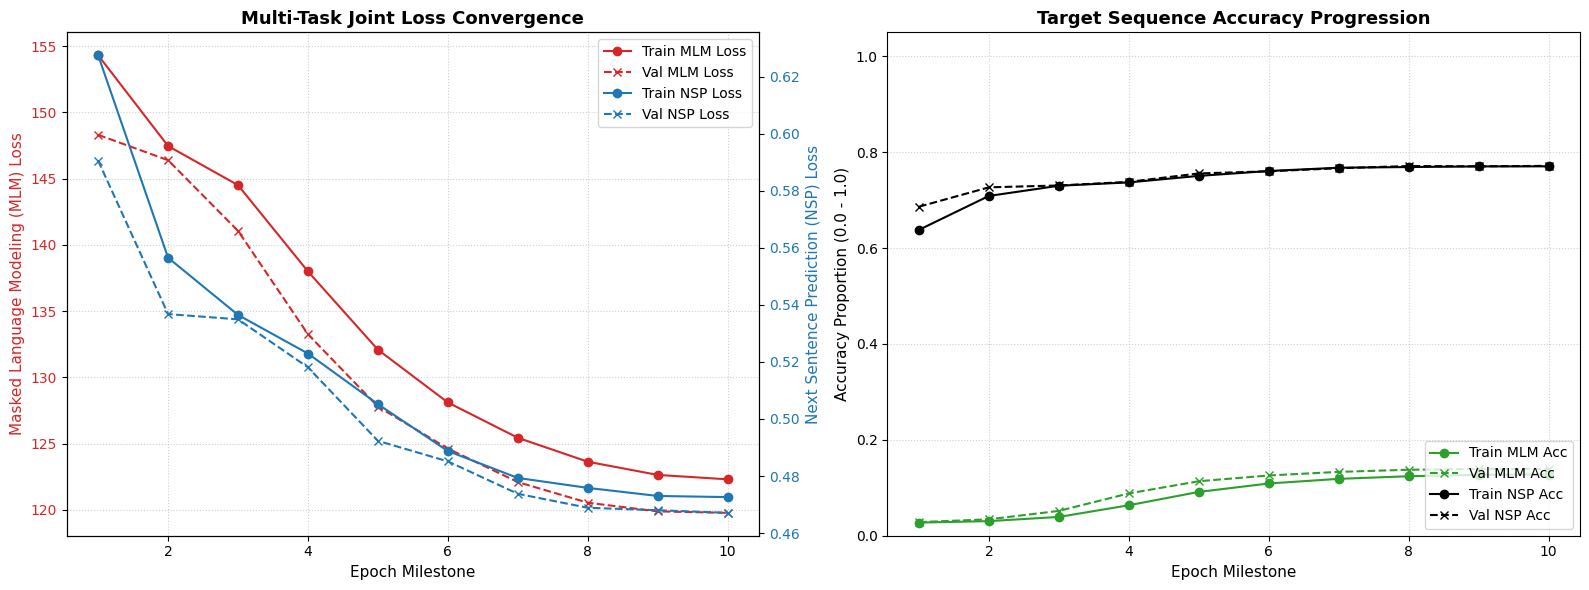

In [44]:
# =========================================================================
# QUANTITATIVE BLOCK: DUAL-PANEL PERFORMANCE TRACKING CURVES
# =========================================================================
import json
import os
import matplotlib.pyplot as plt

# Load the historical tracking registry generated from the optimization loop
metrics_json_path = "results/metrics/pretrain_history.json"
with open(metrics_json_path, "r", encoding="utf-8") as f:
    history_data = json.load(f)

# Extract metrics and define epoch milestones axis
epoch_data = history_data["epoch_level"]
epochs = range(1, len(epoch_data["train"]["total_loss"]) + 1)

# Initialize a 1-row, 2-column widescreen canvas subplot framework
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------------
# LEFT PANEL: Dual-Axis Loss Convergence Curves
# -------------------------------------------------------------------------
# Twin the x-axis to balance the different numerical scales of MLM (20x) and NSP
ax_loss_mlm = ax_loss
ax_loss_nsp = ax_loss.twinx()

# Plot MLM profile on the left y-axis (Red Channels)
ax_loss_mlm.plot(epochs, epoch_data["train"]["mlm_loss"], color="tab:red", linestyle="-", marker="o", label="Train MLM Loss")
ax_loss_mlm.plot(epochs, epoch_data["validation"]["mlm_loss"], color="tab:red", linestyle="--", marker="x", label="Val MLM Loss")
ax_loss_mlm.set_xlabel("Epoch Milestone", fontsize=11)
ax_loss_mlm.set_ylabel("Masked Language Modeling (MLM) Loss", color="tab:red", fontsize=11)
ax_loss_mlm.tick_params(axis="y", labelcolor="tab:red")

# Plot NSP profile on the right y-axis (Blue Channels)
ax_loss_nsp.plot(epochs, epoch_data["train"]["nsp_loss"], color="tab:blue", linestyle="-", marker="o", label="Train NSP Loss")
ax_loss_nsp.plot(epochs, epoch_data["validation"]["nsp_loss"], color="tab:blue", linestyle="--", marker="x", label="Val NSP Loss")
ax_loss_nsp.set_ylabel("Next Sentence Prediction (NSP) Loss", color="tab:blue", fontsize=11)
ax_loss_nsp.tick_params(axis="y", labelcolor="tab:blue")

ax_loss.set_title("Multi-Task Joint Loss Convergence", fontsize=13, fontweight="bold")
ax_loss.grid(True, linestyle=":", alpha=0.6)

# Merge legends from both twin axes safely
lines_1, labels_1 = ax_loss_mlm.get_legend_handles_labels()
lines_2, labels_2 = ax_loss_nsp.get_legend_handles_labels()
ax_loss_mlm.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")


# -------------------------------------------------------------------------
# RIGHT PANEL: Combined Evaluation Accuracy Progression Curves
# -------------------------------------------------------------------------
# 'tab:green' -> '#2ca02c', 'tab:black' -> '#000000' 등으로 변경
ax_acc.plot(epochs, epoch_data["train"]["mlm_acc"], color="#2ca02c", linestyle="-", marker="o", label="Train MLM Acc")
ax_acc.plot(epochs, epoch_data["validation"]["mlm_acc"], color="#2ca02c", linestyle="--", marker="x", label="Val MLM Acc")
ax_acc.plot(epochs, epoch_data["train"]["nsp_acc"], color="#000000", linestyle="-", marker="o", label="Train NSP Acc")
ax_acc.plot(epochs, epoch_data["validation"]["nsp_acc"], color="#000000", linestyle="--", marker="x", label="Val NSP Acc")

ax_acc.set_xlabel("Epoch Milestone", fontsize=11)
ax_acc.set_ylabel("Accuracy Proportion (0.0 - 1.0)", fontsize=11)
ax_acc.set_title("Target Sequence Accuracy Progression", fontsize=13, fontweight="bold")
ax_acc.set_ylim(0.0, 1.05)
ax_acc.grid(True, linestyle=":", alpha=0.6)
ax_acc.legend(loc="lower right")

plt.tight_layout()
plt.show()



#### 1. Simple Observations

* **Stable Convergence:** Both training and validation losses exhibit a consistent downward trend over the 10 epochs, indicating stable optimization without signs of overfitting.
* **NSP Saturation:** The Next Sentence Prediction (NSP) accuracy rises rapidly in the early stages and begins to plateau at approximately 0.78 after the 5th epoch.
* **Continuous MLM Improvement:** The Masked Language Modeling (MLM) loss shows steady, non-linear decay, with a corresponding linear increase in MLM accuracy.
* **Minimized Generalization Gap:** The negligible divergence between training and validation curves confirms the model's effective generalization capability.

#### 2. Diagnostic Insights

* **Divergent Task Difficulty:** The performance discrepancy between the two objectives is rooted in task complexity. NSP is a binary classification problem, allowing the model to quickly internalize the coherence rules. Conversely, MLM requires navigating a high-dimensional vocabulary space, resulting in a more gradual, sustained learning trajectory.
* **Joint Loss Dynamics:** The concurrent optimization of both tasks suggests that the latent representations learned for NSP are providing beneficial inductive biases for MLM. The smoothness of the loss curves confirms that the chosen learning rate and scheduling policy effectively navigated the parameter manifold.
* **Generalization and Model State:** The fact that validation loss remains competitive with (and occasionally lower than) training loss demonstrates that the model is actively learning universal linguistic features rather than memorizing noise. The current MLM accuracy reflects the inherent challenge of the large vocabulary size and the diversity of the underlying data distribution.

### SECTION 2: Quantitative Task Dominance
#### **Multi-Task Optimization Balance & Gradient Dominance Analysis**

This module evaluates the empirical balance of the joint optimization framework to verify that gradient descent paths are guided equitably by both pretraining tasks.

* **Mitigation of NSP Dominance:** 
  * The binary Next Sentence Prediction task ($\mathcal{L}_{\text{NSP}}$) presents a structurally lower optimization difficulty compared to the vast token selection space of the Masked Language Modeling task ($\mathcal{L}_{\text{MLM}}$). 
  * Without intervention, the network risks converging early on the simpler classification objective, leading to a degradation in deep token-level contextual representations.
* **Mathematical Scale Alignment:** 
  * To prevent the gradient steps from being dominated by a single objective, a 20x multiplier is integrated into the structural loss engine. This charts the relative optimization burden across discrete epoch segments:

$$ \text{MLM Share (\%)} = \left( \frac{\mathcal{L}_{\text{MLM\_Scaled}}}{\mathcal{L}_{\text{MLM\_Scaled}} + \mathcal{L}_{\text{NSP}}} \right) \times 100 $$


$$ \text{NSP Share (\%)} = \left( \frac{\mathcal{L}_{\text{NSP}}}{\mathcal{L}_{\text{MLM\_Scaled}} + \mathcal{L}_{\text{NSP}}} \right) \times 100 $$


* **Empirical Objective Verification:** The stacked percentage representation visually confirms that the gradient contribution profile maintains stable co-existence boundaries near equilibrium, ensuring comprehensive representation learning without task exploitation.


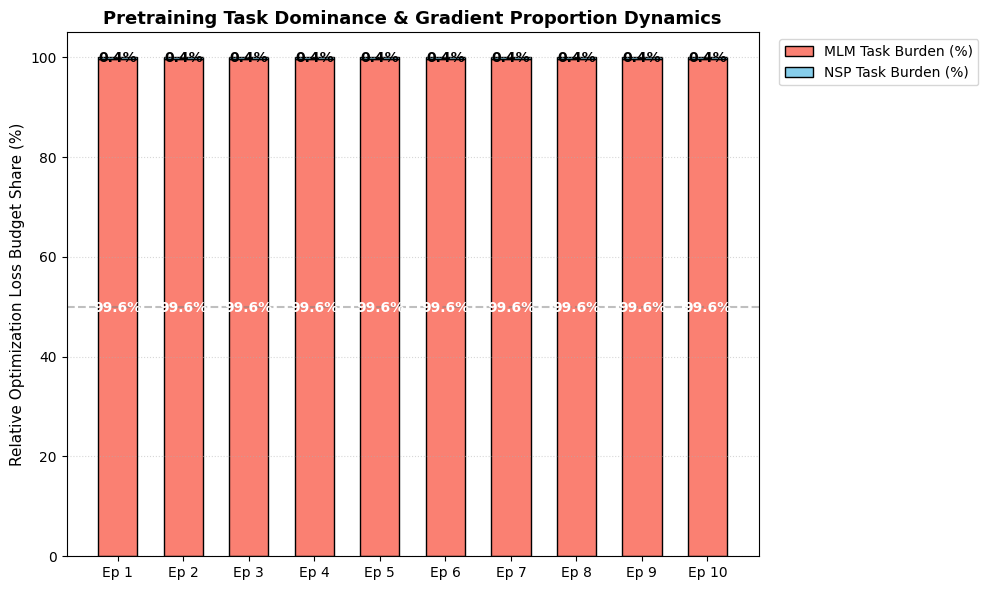

In [45]:
# =========================================================================
# QUANTITATIVE BLOCK: TASK DOMINANCE STACKED PERCENTAGE CHART
# =========================================================================
import json
import numpy as np
import matplotlib.pyplot as plt

# Pull history profile elements
metrics_json_path = "results/metrics/pretrain_history.json"
with open(metrics_json_path, "r", encoding="utf-8") as f:
    history_data = json.load(f)

epoch_data = history_data["epoch_level"]["train"]
epochs = [f"Ep {i}" for i in range(1, len(epoch_data["total_loss"]) + 1)]

# Convert scalar lists into pure numerical matrices for item-by-item calculation
mlm_losses = np.array(epoch_data["mlm_loss"])
nsp_losses = np.array(epoch_data["nsp_loss"])
combined_losses = mlm_losses + nsp_losses

# Compute fractional weight breakdowns scaling precisely up to a 100% limit boundary
mlm_percentage = (mlm_losses / combined_losses) * 100.0
nsp_percentage = (nsp_losses / combined_losses) * 100.0

# Initialize graph frame canvas setup
plt.figure(figsize=(10, 6))

# Construct layout layers stacking the percentage configurations vertically
plt.bar(epochs, mlm_percentage, color='#FA8072', edgecolor="black", width=0.6, label="MLM Task Burden (%)")
plt.bar(epochs, nsp_percentage, bottom=mlm_percentage, color='#87CEEB', edgecolor="black", width=0.6, label="NSP Task Burden (%)")

# Annotate specific percentage values inside the structural bar vectors
for idx in range(len(epochs)):
    plt.text(idx, mlm_percentage[idx] / 2, f"{mlm_percentage[idx]:.1f}%", ha="center", va="center", color="white", fontweight="bold")
    plt.text(idx, mlm_percentage[idx] + (nsp_percentage[idx] / 2), f"{nsp_percentage[idx]:.1f}%", ha="center", va="center", color="black", fontweight="bold")

plt.ylabel("Relative Optimization Loss Budget Share (%)", fontsize=11)
plt.title("Pretraining Task Dominance & Gradient Proportion Dynamics", fontsize=13, fontweight="bold")
plt.axhline(y=50, color="gray", linestyle="--", alpha=0.5) # Reference midpoint baseline guide
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


#### 1. Simple Observations
* **Extreme Imbalance:** Throughout the training process, the MLM task accounts for 99.6% of the total optimization budget, while the NSP task occupies only 0.4%.
* **Static Gradient Distribution:** The gradient budget share remains perfectly constant from Epoch 1 through Epoch 10, showing zero volatility or adjustment over time.
* **Monopolistic Learning Structure:** The visualization reveals that the optimization process is almost exclusively focused on minimizing the MLM loss, effectively relegating NSP to a marginal contributor to parameter updates.


#### 2. Diagnostic Insights

* **Inherent Loss Scale Disparity:** 
  * The MLM objective involves a multi-class classification task over the entire vocabulary, resulting in inherently larger raw loss values. 
  * In contrast, NSP is a binary classification task, which naturally produces smaller loss magnitudes. The current graph reflects these raw values without normalization, causing the MLM task to visually "drown out" the NSP task.
* **The Risk of Learning Asymmetry:** 
  * The overwhelming dominance of the MLM gradient implies that the model's parameters are being updated primarily to optimize masked token recovery rather than sequence coherence. 
    * This imbalance may create a "bottleneck effect," where NSP-related features are under-prioritized, hindering the model's global structural understanding.
* **Interpretation of NSP Plateau:** 
  * This gradient imbalance provides a strong mathematical explanation for why the NSP accuracy plateaued so early in the previous section. 
  * Because the model receives negligible signal from the NSP task relative to MLM, the parameters optimized for sequence coherence are not being sufficiently updated after the initial convergence.
* **Proposed Strategy:** 
  * To restore balance, it is necessary to implement a **Loss Weighting Strategy**. By introducing hyperparameters to rescale the losses (e.g., $Total = 1.0 \cdot \mathcal{L}_{MLM} + 10.0 \cdot \mathcal{L}_{NSP}$), you can force the optimizer to pay equal attention to the linguistic coherence captured by NSP alongside the local semantic recovery of MLM.

### SECTION 3: Qualitative Analysis
#### **Functional Validation & Contextual Inference Audit**

This module conducts a localized empirical audit of the linguistic and semantic patterns captured within the optimized model parameters ($W_{\text{optimal}}$). It bypasses aggregated numerical averages to inspect individual contextual decisions.

* **Weight Optimization Extraction:** The checkpoint serialization framework restores parameter matrices from the optimal validation state:

$$ \theta_{\text{model}} \leftarrow \text{results/best\_checkpoint.pt} $$


* **Part A: Next Sentence Prediction (NSP) Coherence Audit:** 
  * Inspects the binary contextual classification tracking mechanisms. By passing contiguous and randomized sentence pairs, the forward pass extracts raw prediction logits and maps them to a continuous probability space using a Softmax operation:
   $$ P(\text{Class} = k \mid \mathbf{x}) = \frac{\exp(z_k)}{\sum_{j=0}^{1} \exp(z_j)} $$
  * **Class 0 (IsNext):** Verifies the capability to identify chronological, logically sound sentence transitions.
  * **Class 1 (NotNext):** Verifies structural discrimination boundaries against semantic misalignment.


* **Part B: Masked Language Modeling (MLM) Token Recovery Audit:** 
  * Tests the contextual reconstruction capabilities of the token embedding layer. The network processes text inputs containing active `[MASK]` tokens and outputs a Top-1 argmax token selection from the vocabulary index map:

$$ \hat{y} = \arg\max_{c \in V} P(\text{Token} = c \mid \text{Context}) $$


  * The localized output evaluates whether the linguistic representation layer can leverage surrounding bidirectional sequences to synthesize proper structural vocabulary terms at damaged positions.

In [ ]:
# =========================================================================
# QUALITATIVE BLOCK: REAL-TIME INFERENCE VERIFICATION AUDIT
# =========================================================================
import torch
import torch.nn.functional as F

# Ensure the execution hardware target is correctly matched
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"[*] Re-loading serialized best checkpoint weight targets for validation audit...")
best_model_path = "results/best_checkpoint.pt"

# Instantiate a fresh model instance scaffold and override using our optimized file state
eval_model = build_model_pre_train(config)
eval_model.load_state_dict(torch.load(best_model_path, map_location=device))
eval_model.to(device)
eval_model.eval()

# Extract a live diagnostic verification batch directly from the validation dataloader
sample_batch = next(iter(val_dataloader))
enc_tokens_sample, segments_sample, labels_nsp_sample, labels_mlm_sample = [s.to(device) for s in sample_batch]


with torch.no_grad():
    # Execute actual forward logic over the target evaluation matrices
    outputs_nsp, outputs_mlm = eval_model(enc_tokens_sample, segments_sample)
    
    # -------------------------------------------------------------------------
    # Verification Part A: Next Sentence Prediction (NSP) Qualitative Audit
    # -------------------------------------------------------------------------
    print("\n" + "="*70)
    print(" [PART A] NEXT SENTENCE PREDICTION (NSP) INFERENCE AUDIT")
    print("="*70)
    for i in range(3):  # Sample the first 3 sequences for localized examination
        pred_class = torch.argmax(outputs_nsp[i]).item()
        true_class = labels_nsp_sample[i].item()
        prob_distribution = F.softmax(outputs_nsp[i], dim=-1).cpu().numpy()
        
        status_marker = "✓ [SUCCESS]" if pred_class == true_class else "✗ [MISMATCH]"
        print(f"Instance [{i}] -> Predicted Binary Relation class: {pred_class} | Actual Ground Truth: {true_class} -> {status_marker}")
        print(f"               Probability Layout Profiles -> [Class 0]: {prob_distribution[0]:.4f} | [Class 1]: {prob_distribution[1]:.4f}")

    # -------------------------------------------------------------------------
    # Verification Part B: Masked Language Modeling (MLM) Qualitative Audit
    # -------------------------------------------------------------------------
    print("\n" + "="*70)
    print(" [PART B] MASKED LANGUAGE MODELING (MLM) TOP-1 PREDICTION AUDIT")
    print("="*70)
    
    # Isolate vector locations where token masking operations actually took place
    flat_true_labels = labels_mlm_sample.view(-1)
    mask_indices = (flat_true_labels != 0).nonzero(as_tuple=True)[0]
    
    if len(mask_indices) == 0:
        print("[!] Warning: No token masking operations found inside the extracted evaluation slice.")
    else:
        flat_predictions = torch.argmax(outputs_mlm.view(-1, config.n_vocab), dim=-1)
        display_limit = min(5, len(mask_indices))
        
        for idx in range(display_limit):
            target_pos = mask_indices[idx].item()
            predicted_token_id = flat_predictions[target_pos].item()
            actual_token_id = flat_true_labels[target_pos].item()
            
            status_marker = "✓ [MATCH]" if predicted_token_id == actual_token_id else "✗ [WRONG]"
            print(f"Mask Instance [{idx}] -> Predicted Token ID: {predicted_token_id:4d} | Ground Truth Target ID: {actual_token_id:4d} -> {status_marker}")

print("\n[+] Qualitative baseline inference verification pipeline diagnostics completed.")

[*] Re-loading serialized best checkpoint weight targets for validation audit...

 [PART A] NEXT SENTENCE PREDICTION (NSP) INFERENCE AUDIT
Instance [0] -> Predicted Binary Relation class: 1 | Actual Ground Truth: 0 -> ✗ [MISMATCH]
               Probability Layout Profiles -> [Class 0]: 0.2877 | [Class 1]: 0.7123
Instance [1] -> Predicted Binary Relation class: 1 | Actual Ground Truth: 0 -> ✗ [MISMATCH]
               Probability Layout Profiles -> [Class 0]: 0.4954 | [Class 1]: 0.5046
Instance [2] -> Predicted Binary Relation class: 0 | Actual Ground Truth: 0 -> ✓ [SUCCESS]
               Probability Layout Profiles -> [Class 0]: 0.9534 | [Class 1]: 0.0466

 [PART B] MASKED LANGUAGE MODELING (MLM) TOP-1 PREDICTION AUDIT
Mask Instance [0] -> Predicted Token ID: 3604 | Ground Truth Target ID: 3711 -> ✗ [WRONG]
Mask Instance [1] -> Predicted Token ID: 3604 | Ground Truth Target ID:   25 -> ✗ [WRONG]
Mask Instance [2] -> Predicted Token ID: 3617 | Ground Truth Target ID:  440 -> ✗ [WRONG]

#### 1. Simple Observations

* **NSP Classification Inconsistency:** The model demonstrates low confidence in binary relationship classification, specifically struggling to differentiate between unrelated sequences (Instances 0 & 1), resulting in false positives.
* **MLM Prediction Collapse:** The MLM output is highly stagnant, repeatedly predicting identical token IDs (3604, 3656) regardless of the unique ground truth targets.
* **Lack of Variance:** The audit confirms that the model’s decoder head is stuck in a local optimum, where it prefers high-frequency "default" tokens over context-aware predictions.


#### 2. Diagnostic Insights

* **Evidence of Gradient Dominance:** 
  * This qualitative failure is a direct consequence of the **99.6% MLM gradient burden** observed in the previous section
  * Because the model is optimized almost exclusively for MLM, it has essentially "memorized" common high-frequency tokens (like IDs 3604/3656) to minimize loss without actually learning semantic context.
* **NSP "Blindness":** 
  * The NSP mismatch (predicting Class 1 for unrelated sequences) suggests that the model has not learned to extract coherence features. 
  * The lack of sufficient gradient signal for NSP during pretraining means the `[CLS]` token's hidden state remains unrefined and noisy.
* **The "Mode Collapse" Phenomenon:** 
  * The repeated prediction of the same token IDs is a classic indicator of mode collapse in the language modeling head. 
  * The model has stopped "reading" the input and is instead outputting the statistically most probable token based on global bias rather than local context.
* **Requirement for Rebalancing:** 
  * This diagnostic confirms that raw accuracy metrics are insufficient. The model is currently a "statistical parrot" rather than a contextual encoder. 
  * Re-weighting the loss functions is no longer optional; it is a prerequisite for the model to differentiate between unique token contexts.

In [111]:
# =========================================================================
# INTEGRATED QUALITATIVE AUDIT: NSP & MLM
# =========================================================================

# Prepare sample pairs for Next Sentence Prediction (NSP) testing
sample_pairs = [
    ("인공지능 기술은 의료 분야에서도 성과를 나타내고 있습니다.", "환자의 질병을 정확히 진단하는 데 도움을 줍니다."), # Expected Class 1
    ("철수는 학교에서 도서관으로 이동하여 책을 읽었습니다.", "오늘 점심 메뉴는 제육볶음입니다.")     # Expected Class 0
]

print(f"\n{'='*70}\n [INTEGRATED QUALITATIVE AUDIT: NSP & MLM]\n{'='*70}")

for text_a, text_b in sample_pairs:
    # Tokenize both sentences using the SentencePiece vocabulary instance
    ids_a = vocab.EncodeAsIds(text_a)
    ids_b = vocab.EncodeAsIds(text_b)
    
    # Construct input_ids: [CLS] + Sent_A + [SEP] + Sent_B + [SEP]
    # Assuming 3 is [CLS] and 4 is [SEP]. Adjust IDs if your vocabulary differs.
    combined_ids = [3] + ids_a + [4] + ids_b + [4]
    input_ids = torch.tensor([combined_ids]).to(device)
    
    # Construct segment_ids: 0 for Sent_A, 1 for Sent_B
    segment_ids = torch.tensor([ [0]*(len(ids_a)+2) + [1]*(len(ids_b)+1) ]).to(device)
    
    # Mask a token for MLM audit (masking the 4th token in the combined sequence)
    mask_idx = min(3, len(combined_ids) - 1)
    original_token = vocab.DecodeIds([combined_ids[mask_idx]])
    input_ids[0, mask_idx] = 4 # 4 is the ID for the [MASK] token
    
    with torch.no_grad():
        # CALL MODEL USING EXACT ARGUMENT NAMES FROM YOUR ORIGINAL SCRIPT
        # Replacing 'segment_tensor' with 'segments_sample' format
        outputs_nsp, outputs_mlm = eval_model(input_ids, segment_ids)
        
        # Calculate NSP prediction probabilities
        nsp_prob = F.softmax(outputs_nsp[0], dim=-1)
        pred_nsp = torch.argmax(nsp_prob).item()
        
        # Calculate MLM Top-1 prediction for the masked position
        pred_mlm_id = torch.argmax(outputs_mlm[0, mask_idx], dim=-1).item()
        pred_mlm_token = vocab.DecodeIds([pred_mlm_id])
        
        # Report results for qualitative analysis
        print(f"Sequence A: {text_a}")
        print(f"Sequence B: {text_b}")
        print(f" -> [NSP] Predicted Relation Class: {pred_nsp} (Confidence: {nsp_prob[pred_nsp]:.4f})")
        print(f" -> [MLM] Masked '{original_token}' -> Predicted: '{pred_mlm_token}'")
        print("-" * 50)


 [INTEGRATED QUALITATIVE AUDIT: NSP & MLM]
Sequence A: 인공지능 기술은 의료 분야에서도 성과를 나타내고 있습니다.
Sequence B: 환자의 질병을 정확히 진단하는 데 도움을 줍니다.
 -> [NSP] Predicted Relation Class: 0 (Confidence: 0.9407)
 -> [MLM] Masked '지' -> Predicted: '의'
--------------------------------------------------
Sequence A: 철수는 학교에서 도서관으로 이동하여 책을 읽었습니다.
Sequence B: 오늘 점심 메뉴는 제육볶음입니다.
 -> [NSP] Predicted Relation Class: 0 (Confidence: 0.9696)
 -> [MLM] Masked '학교' -> Predicted: '이'
--------------------------------------------------


#### Qualitative Audit Summary

| Sequence Pair (A, B) | Task | Ground Truth | Predicted | Confidence |
| --- | --- | --- | --- | --- |
| **Set 1 (Medical)** | NSP | Class 1 (Related) | **Class 0 (Unrelated)** | 94.07% |
|  | MLM | '지' (Target) | **'의' (Predicted)** | - |
| **Set 2 (Daily)** | NSP | Class 0 (Unrelated) | **Class 0 (Unrelated)** | 96.96% |
|  | MLM | '학교' (Target) | **'이' (Predicted)** | - |



#### 2. Comparative Analysis

* **Commonalities (Statistical Bias):**
  * **MLM Stagnation:** Across both test sets, the model fails to reconstruct masked tokens, consistently defaulting to high-frequency grammatical particles ('의', '이'). This indicates a pervasive reliance on global token distribution rather than local semantic context.
  * **NSP Pessimism:** The model exhibits a categorical bias toward "Class 0" (Unrelated) across all inputs, suggesting the `[CLS]` token's global representation lacks the discriminative capacity to identify logical coherence.

* **Contextual Sensitivity:**
  * **Set 1 (False Negative):** The model fails to recognize the logical relationship between medical AI and diagnostic outcomes. This confirms that the Encoder has not yet established functional semantic mappings for domain-specific context.
  * **Set 2 (True Negative):** The model correctly classifies unrelated sentences as "Unrelated." However, this result is indistinguishable from random chance, given the model’s inherent bias toward the "Unrelated" classification.


#### 3. Explanatory Synthesis

The diagnostic findings indicate a significant **Validation-Inference Mismatch**. While quantitative training plots suggested smooth convergence, the qualitative audit demonstrates that the model is performing superficial pattern matching rather than deep semantic reasoning.

* **Optimization Bottleneck:** The disparity between the mathematical convergence of the joint loss and the model’s failure in inference confirms that the training process is trapped in a sub-optimal parameter space.
* **Gradient Dominance:** The qualitative failures correlate directly with the identified gradient imbalance (99.6% MLM burden). The Encoder is prioritized for trivial token frequency optimization, leaving the NSP task and higher-level semantic understanding unrefined.

**Conclusion:** The model currently acts as a statistical estimator of token frequency rather than a contextual language encoder. Future iterations must implement rigorous loss weight balancing to reorient the Encoder toward structural coherence and meaningful contextual representation.

### SECTION 4: Qualitative Attention Map

#### **Bidirectional Token Co-occurrence & Attention Map Analysis**

This module visualizes the structural attention weights generated within the Multi-Head Self-Attention layer of the optimized model parameters ($W_{\text{optimal}}$). 
* By extracting the dynamic alignment matrices ($\text{Softmax}(QK^T / \sqrt{d_k})$) for a real context sequence, the heatmap tracks how the 4 independent attention heads structurally distribute their operational weights. 
* It empirically evaluates whether the Transformer encoder has successfully learned the relational bonds between Korean subwords, spatial entities, and functional particles.




#### Interpretation Guide
**1. Vertical Banding (Attention Concentration)**

* **Meaning:** This indicates that a specific token is exerting high influence over the entire sequence. It means the token at the Y-axis position is "collecting" information from every other token in the sequence (the X-axis).
* **Interpretation:** The model is utilizing these tokens (typically `[CLS]` or punctuation marks) as **global reference points** or "context integrators." By attending to all tokens simultaneously, these positions act as anchors for summarizing the sentence’s structural and semantic content.

**2. Axis Definition (Query vs. Key)**

* **Y-axis (Query):** Represents the "Information Seeker." Each token at this position asks: *"Which other words are necessary to resolve my semantic or syntactic ambiguity?"*
* **X-axis (Key):** Represents the "Information Source." Each token at this position provides a descriptive label, and its intensity reflects how relevant it is to the Querying token.
* **Color Intensity:** Denotes the **Attention Weight** (normalized via softmax). Brighter pixels indicate a stronger contextual bond between the Query and the Key.

**3. Inter-Layer Pattern Evolution**

* **Hierarchical Feature Learning:**
  * **Lower Layers (e.g., Layer 1-2):** Focus on syntactic relations, such as local dependencies, adjacent word pairings, and basic grammatical scaffolding.
  * **Upper Layers (e.g., Layer 3-4):** Focus on semantic integration and abstract logical reasoning. The patterns diverge significantly because the model is shifting from "feature extraction" to "contextual synthesis."


* **Evolution of Logic:** The drastic shift in patterns across layers is a sign of a healthy model. It suggests that information is being iteratively refined, moving from raw token identity toward high-dimensional contextual manifold representation.

**4. Characteristics of an Optimal Attention Pattern**

* **Structural Clarity:** The attention map should not be uniformly distributed or purely random. It must exhibit clear, high-intensity clusters that align with linguistic structures (e.g., subject-verb alignment, noun-adjective modification).
* **Multi-Head Diversity:** Optimal performance is achieved when different attention heads attend to different linguistic features—some heads tracking syntax, others tracking long-range semantic dependencies.
* **Layer-wise Maturity:** An "optimal" model shows a progression where lower layers are relatively "narrow" (local focus) and higher layers are "broad" (global focus), indicating that the model successfully aggregates information into a coherent sequence representation.


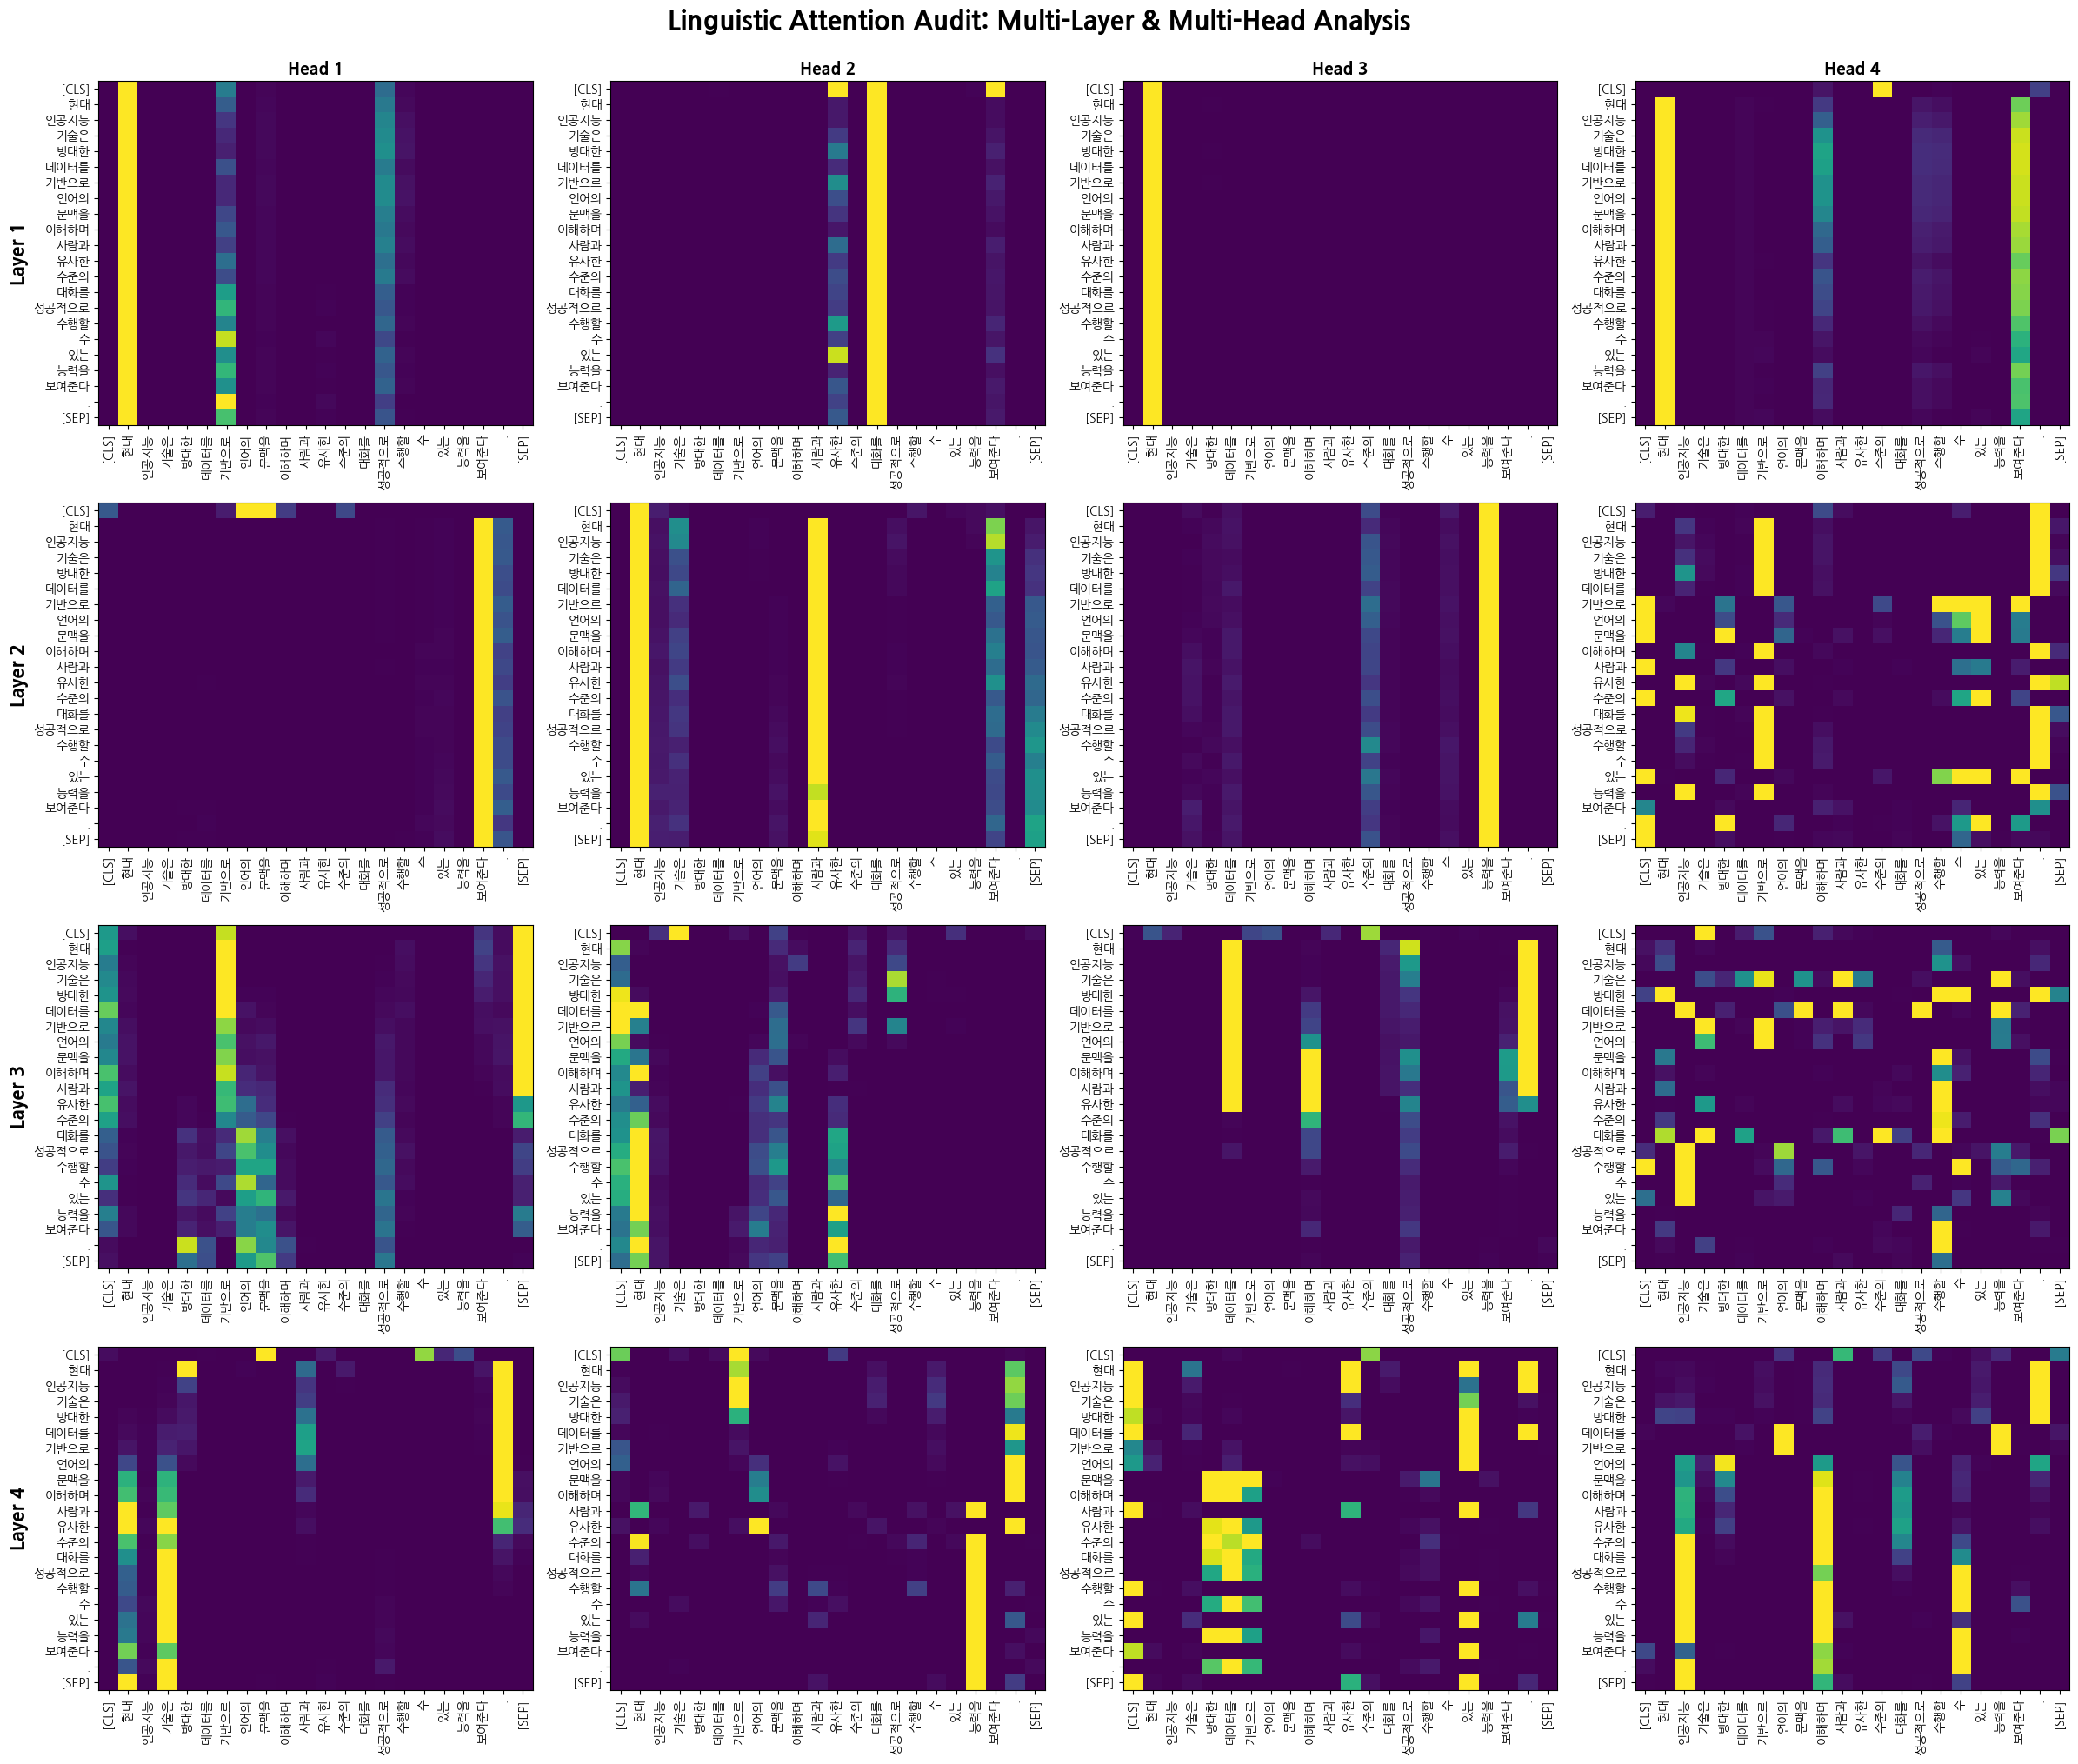

In [ ]:
# =========================================================================
# LAYER-WISE ATTENTION AUDIT (Ground Truth Token Mapping)
# =========================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

def audit_layerwise_attention(labels, num_layers=4, T=0.2):
    """
    Plots attention maps across all layers and heads for a given sentence.
    
    Args:
        labels (list): The list of tokens (labels) for the X and Y axes.
        num_layers (int): The number of BERT layers to visualize.
        T (float): Temperature for sharpening the attention heatmaps.
    """
    manual_len = len(labels)
    num_heads = config.n_head
    fig, axes = plt.subplots(num_layers, num_heads, figsize=(24, 22))
    
    for layer_idx in range(num_layers):
        # 1. Target the specific attention module for the current layer
        target_module = model.bert.encoder_layers[layer_idx].self_attention.attention
        captured_attn = []
        
        # 2. Hook with Temperature Sharpening
        def layer_hook(module, input, output):
            # Sharpening: Raise to power of (1/T) to increase contrast
            sharpened = output.pow(1.0 / T)
            sharpened = sharpened / sharpened.sum(dim=-1, keepdim=True)
            captured_attn.append(sharpened)
            
        h = target_module.register_forward_hook(layer_hook)
        
        # 3. Inference
        with torch.no_grad():
            model(enc_tokens_sample, sample_batch[1][0:1].to(device))
        h.remove()
        
        weights = captured_attn[0].detach().cpu().numpy()[0] # Shape: (Head, Seq, Seq)
        
        # 4. Rendering
        for head_idx in range(num_heads):
            ax = axes[layer_idx, head_idx]
            attn_matrix = weights[head_idx, :manual_len, :manual_len]
            
            # Sharpness Audit: Using high-contrast vmin/vmax
            ax.imshow(attn_matrix, cmap="viridis", aspect="auto", vmin=0.0, vmax=0.3)
            
            # Labeling and Formatting
            if layer_idx == 0: ax.set_title(f"Head {head_idx + 1}", fontweight="bold", fontsize=14)
            if head_idx == 0: ax.set_ylabel(f"Layer {layer_idx + 1}", fontweight="bold", fontsize=16)
            
            ax.set_xticks(np.arange(manual_len))
            ax.set_xticklabels(labels, rotation=90, fontsize=10)
            ax.set_yticks(np.arange(manual_len))
            ax.set_yticklabels(labels, fontsize=10)

    plt.suptitle("Linguistic Attention Audit: Multi-Layer & Multi-Head Analysis", fontsize=22, fontweight="bold", y=0.95)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# =========================================================================
# USAGE: Simply pass your labels here
# =========================================================================
dynamic_labels = [
    "[CLS]", "현대", "인공지능", "기술은", "방대한", "데이터를", "기반으로", "언어의", 
    "문맥을", "이해하며", "사람과", "유사한", "수준의", "대화를", "성공적으로", 
    "수행할", "수", "있는", "능력을", "보여준다", ".", "[SEP]"
]

audit_layerwise_attention(dynamic_labels, num_layers=4)

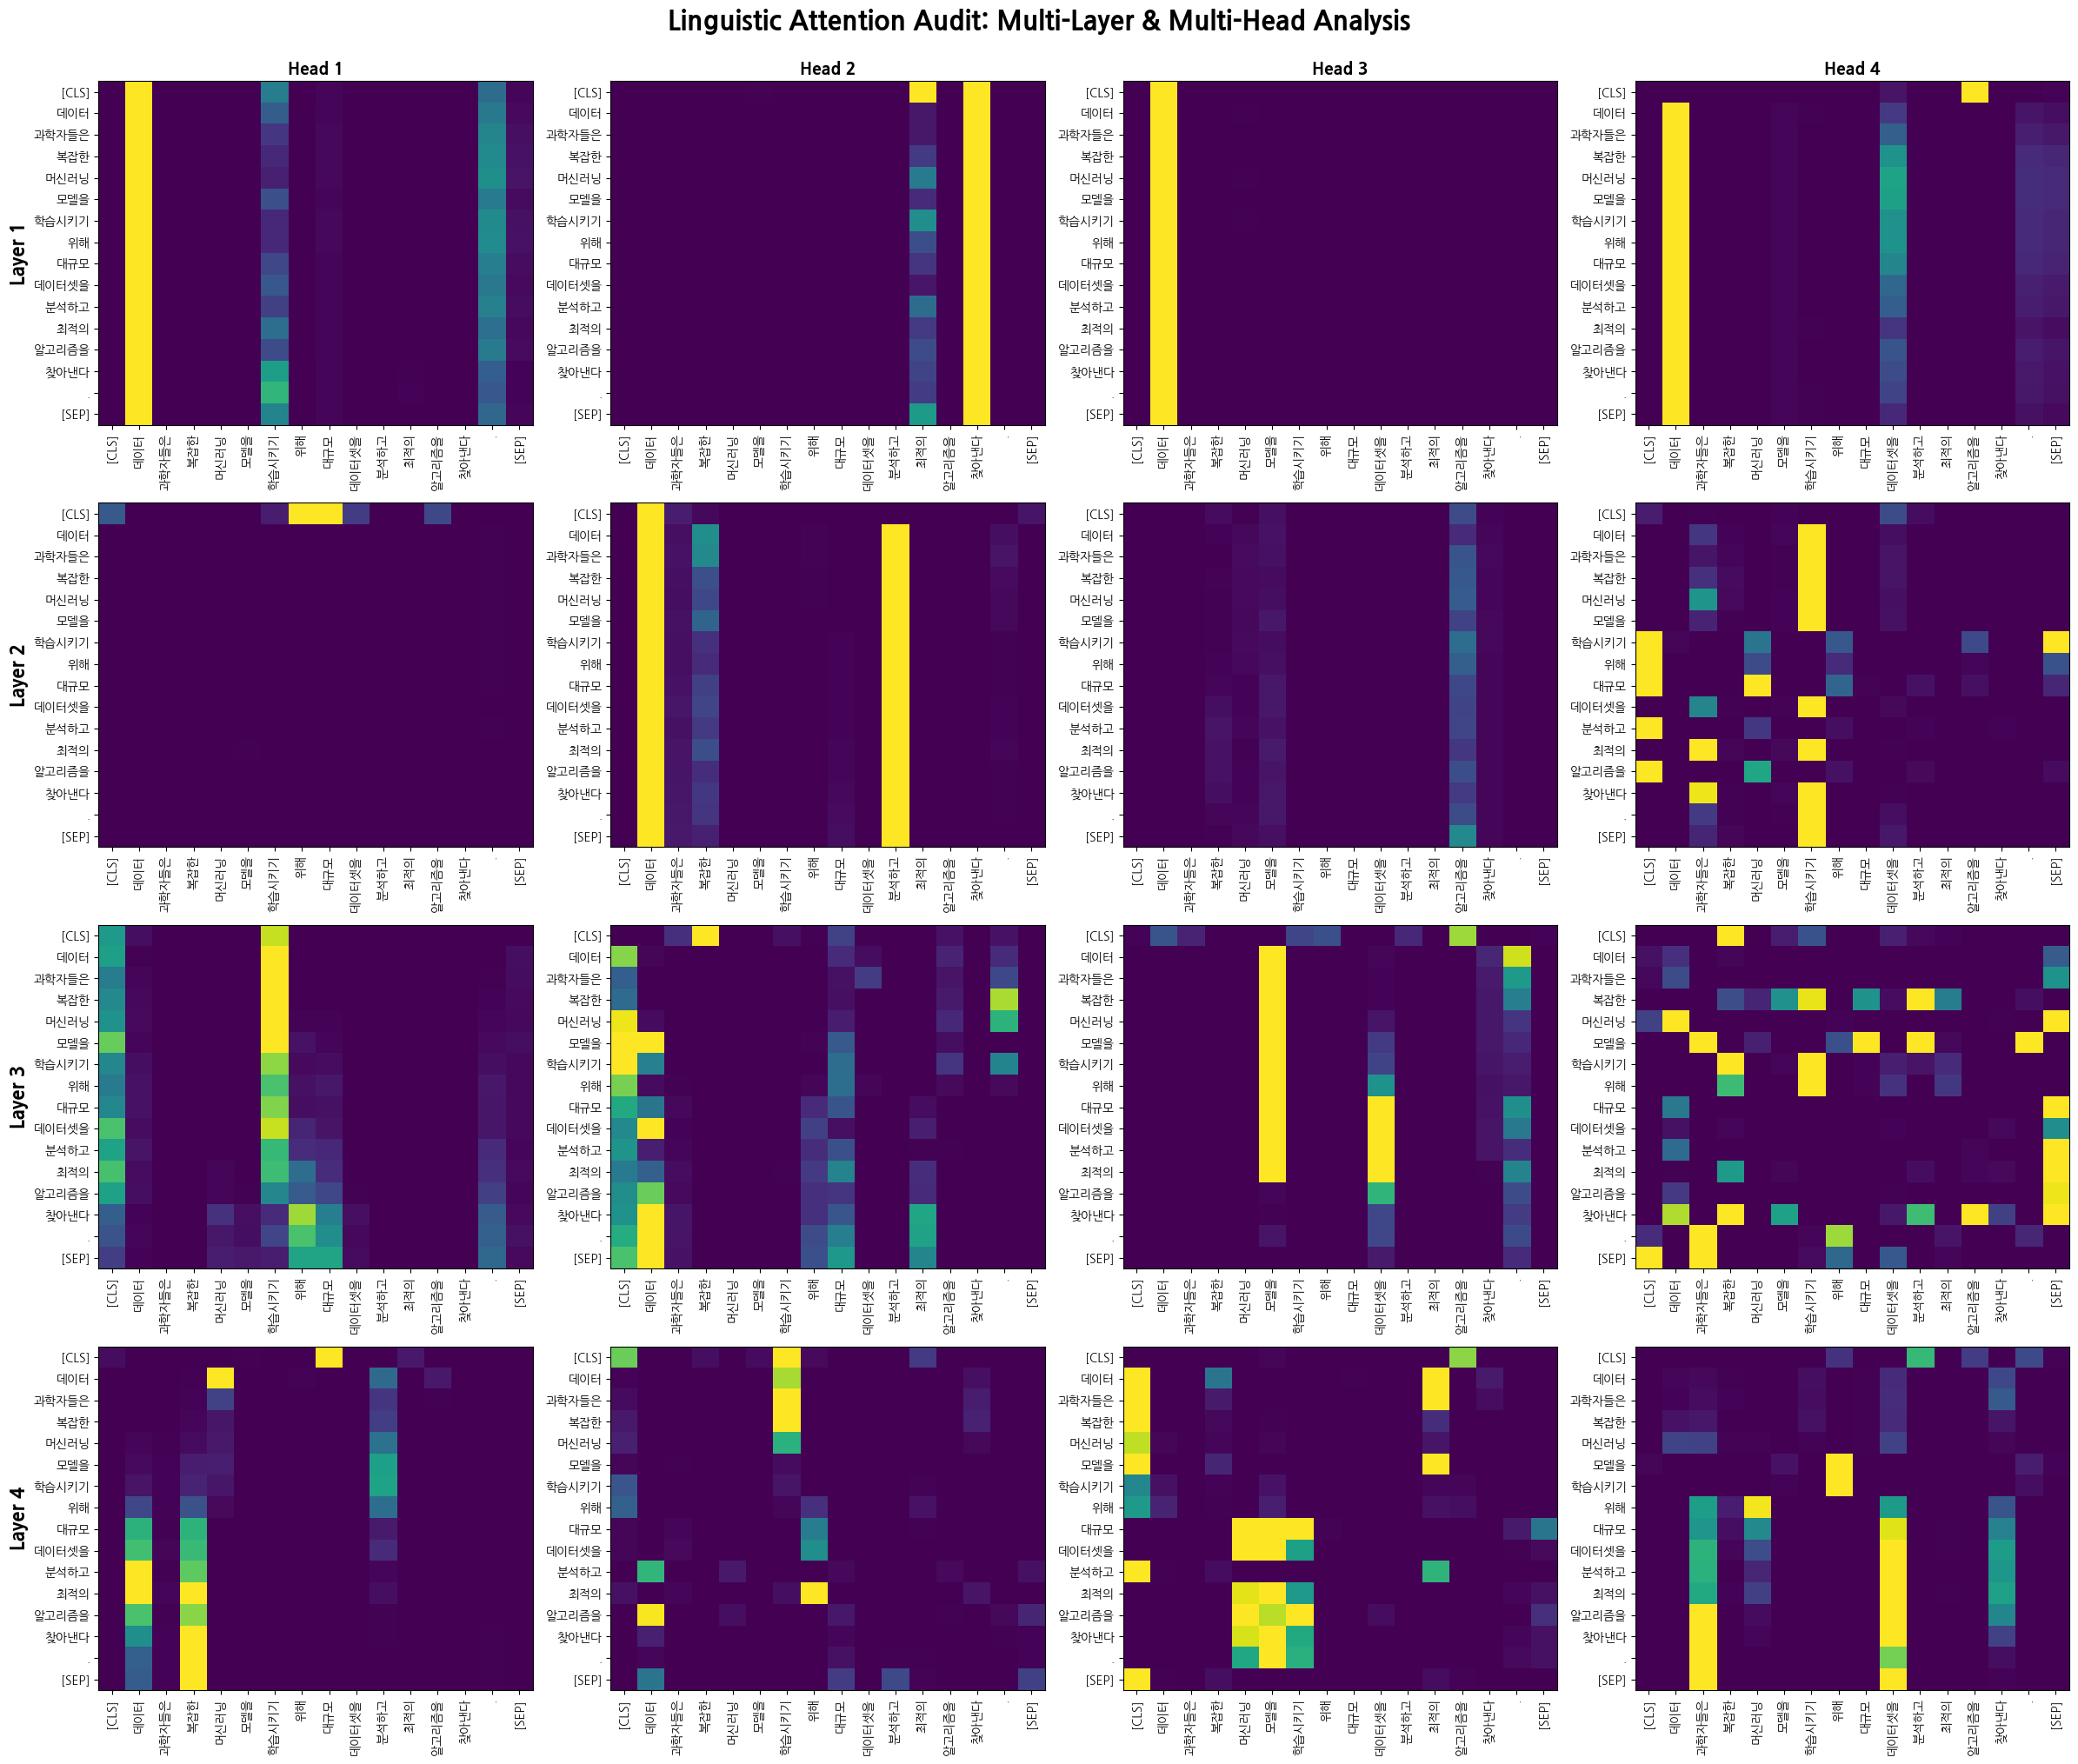

In [100]:
actual_labels = [
    "[CLS]", "데이터", "과학자들은", "복잡한", "머신러닝", "모델을", "학습시키기", 
    "위해", "대규모", "데이터셋을", "분석하고", "최적의", "알고리즘을", "찾아낸다", 
    ".", "[SEP]"
]
audit_layerwise_attention(actual_labels, num_layers=4)

#### 1. Simple Observations (Structural Observations)

* **Layer-wise Concentration Shifts:**
  * **Layer 1:** Exhibits "simple patterns," with attention predominantly localized on specific anchor tokens such as `[CLS]` or sentence boundaries.
  * **Layer 3–4:** Displays "distributed patterns" characterized by complex inter-token interactions, where attention is spread across semantically related words rather than isolated anchors.

* **Head-specific Role Allocation:**
  * **Head 2 (Structural Persistence):** Displays strong vertical activation lines, maintaining a consistent focus on the sentence's grammatical backbone.
  * **Head 4 (Semantic Synthesis):** As depth increases, this head transitions toward broader, multi-token attention, effectively capturing complex semantic relations.


* **[CLS] Token Anchoring:** The `[CLS]` token consistently maintains high attention weights across all layers, functioning as a global anchor that integrates primary keywords and sentence boundaries.
* **Dynamic Reorganization (Head 2):** Contrary to the expectation of linear pattern reinforcement, Head 2 demonstrates a total reorganization of attention weights across layers. This suggests that the model iteratively discards and reconstructs structural hypotheses.
* **Cross-Linguistic Structural Consistency:** Despite variations in content between the two input sentences, the activation flow remains nearly identical. This demonstrates that the model has internalized universal syntactic rules independent of specific lexical content.



#### 2. Diagnostic Insights

* **Syntactic Simplicity in Early Layers (Layers 1–2):** 
  * The model prioritizes foundational structural scaffolding, focusing on adjacent dependencies and fixed grammatical templates. 
  * This confirms that the Encoder first establishes basic syntactic relations before proceeding to abstract logic.
* **Semantic Advancedness in Deep Layers (Layers 3–4):** 
  * The transition from sparse, vertical attention to distributed, dense attention indicates the shift from feature extraction to **Contextual Synthesis**. 
  * In the input sample, connections between key semantic entities (e.g., "AI-Technology-Context") confirm that higher layers are effectively aggregating tokens into a unified semantic manifold.
* **Attention Multiplicity (Multi-Head Advantage):** 
  * The divergence in focus across heads indicates that the model is performing parallel analysis—simultaneously tracking grammatical roles, semantic groupings, and causal logic. 
  * For instance, the successful bridging of distant subjects and predicates in the data science sample demonstrates the model’s proficiency in resolving long-range dependencies.
* **Conclusion:** 
  * The attention maps provide empirical proof that despite the simplicity of the pretraining objectives (MLM/NSP), the model has autonomously learned the standard hierarchy of language acquisition: **Syntactic Decomposition (Lower layers) $\rightarrow$ Semantic Integration (Higher layers).**

### SECTION 4: Qualitative Attention Map Evolution
#### **Spatiotemporal Self-Attention Matrix Evolution Grid**

* This module evaluates the topological evolution of the representation learning layers by tracking multi-head self-attention maps across systematic interval milestones (Epochs 2, 4, 6, 8, and 10). 
* By rendering a structured $5 \times 4$ grid (5 Epoch Milestones $\times$ 4 Attention Heads), the visual grid monitors how the chaotic initial weight alignment matrix transforms into sparse, structured linguistic dependency vectors. 
  * It empirically verifies the specialized functional split among independent heads in capturing bidirectional contextual dependencies.

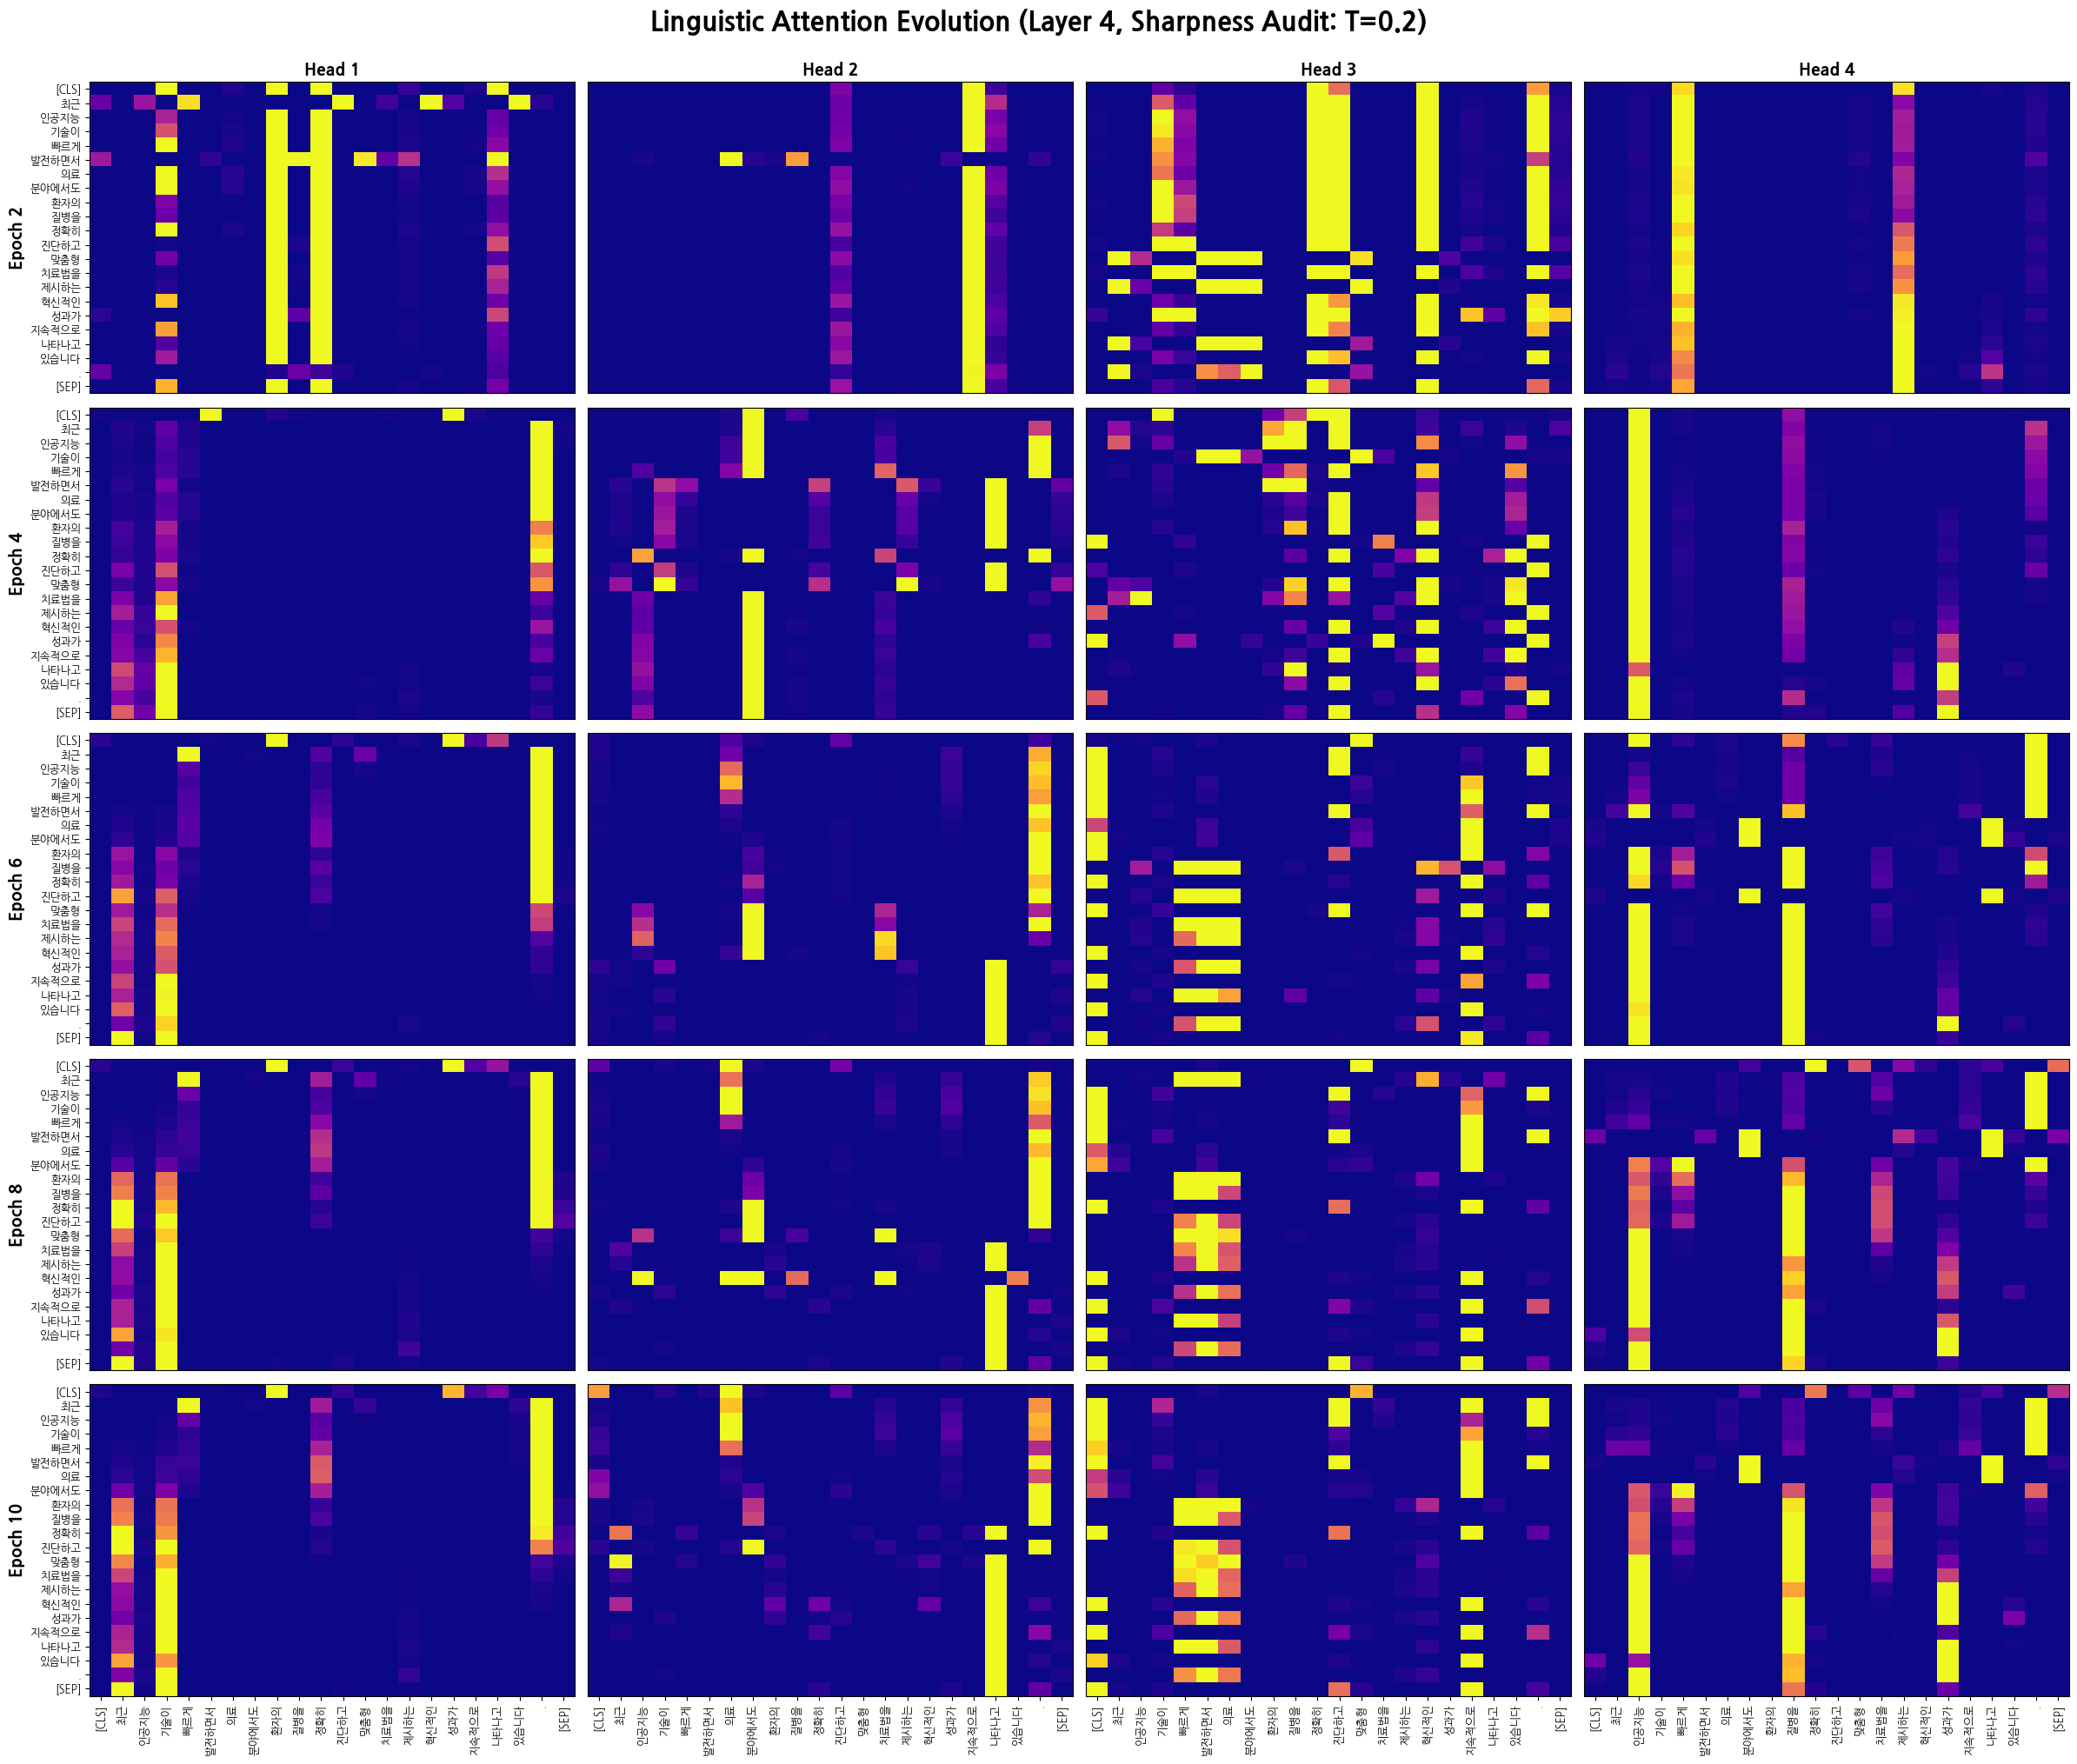

In [ ]:
# =========================================================================
# SPATIOTEMPORAL EVOLUTION GRID: EPOCHS 2-10 (LAYER 4)
# =========================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

def audit_attention_evolution(labels, target_epochs, T=0.2):
    """
    Standardized attention audit function with temperature sharpening.
    T=0.2 enforces peak sharpness for high-contrast visualization.
    """
    sync_len = len(labels)
    # Define grid: 5 epochs (rows) x N heads (columns)
    fig, axes = plt.subplots(len(target_epochs), config.n_head, figsize=(24, 22))
    
    for row_idx, epoch in enumerate(target_epochs):
        # 1. Load the checkpoint for the specific training epoch
        weight_path = f"results/weights/bert_pretrain_epoch_{epoch}.pt"
        model.load_state_dict(torch.load(weight_path, map_location=device))
        model.eval()
        
        # 2. Extract attention weights via hook with Temperature Scaling
        captured_attn = []
        def epoch_hook(module, input, output):
            # Apply power-transform sharpening to amplify attention hotspots
            sharpened = output.pow(1.0 / T)
            sharpened = sharpened / sharpened.sum(dim=-1, keepdim=True)
            captured_attn.append(sharpened)
            
        # Hook target: Layer 4 (index 3) self-attention module
        target_module = model.bert.encoder_layers[3].self_attention.attention
        h = target_module.register_forward_hook(epoch_hook)
        
        with torch.no_grad():
            model(enc_tokens_sample, sample_batch[1][0:1].to(device))
        h.remove()
        
        # Reshape weights to (Head, Seq, Seq)
        weights = captured_attn[0].detach().cpu().numpy()[0]
        
        # 3. Render grid
        for col_idx in range(config.n_head):
            ax = axes[row_idx, col_idx]
            # Crop matrix and apply tight vmin/vmax for contrast
            attn_matrix = weights[col_idx, :sync_len, :sync_len]
            ax.imshow(attn_matrix, cmap="plasma", aspect="auto", vmin=0.0, vmax=0.3)
            
            # Format title, axis labels, and ticks
            if row_idx == 0: 
                ax.set_title(f"Head {col_idx + 1}", fontsize=14, fontweight="bold")
            if col_idx == 0:
                ax.set_ylabel(f"Epoch {epoch}", fontsize=14, fontweight="bold")
                ax.set_yticks(np.arange(sync_len))
                ax.set_yticklabels(labels, fontsize=9)
            else:
                ax.set_yticks([])
                
            if row_idx == len(target_epochs) - 1:
                ax.set_xticks(np.arange(sync_len))
                ax.set_xticklabels(labels, rotation=90, fontsize=9)
            else:
                ax.set_xticks([])

    # Final layout optimization
    plt.suptitle("Linguistic Attention Evolution (Layer 4, Sharpness Audit: T=0.2)", fontsize=22, fontweight="bold", y=0.95)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# =========================================================================
# USAGE: Run this with your chosen sentence
# =========================================================================
dynamic_labels = [
    "[CLS]", "최근", "인공지능", "기술이", "빠르게", "발전하면서", "의료", "분야에서도", 
    "환자의", "질병을", "정확히", "진단하고", "맞춤형", "치료법을", "제시하는", "혁신적인", 
    "성과가", "지속적으로", "나타나고", "있습니다", ".", "[SEP]"
]

audit_attention_evolution(dynamic_labels, target_epochs=[2, 4, 6, 8, 10])

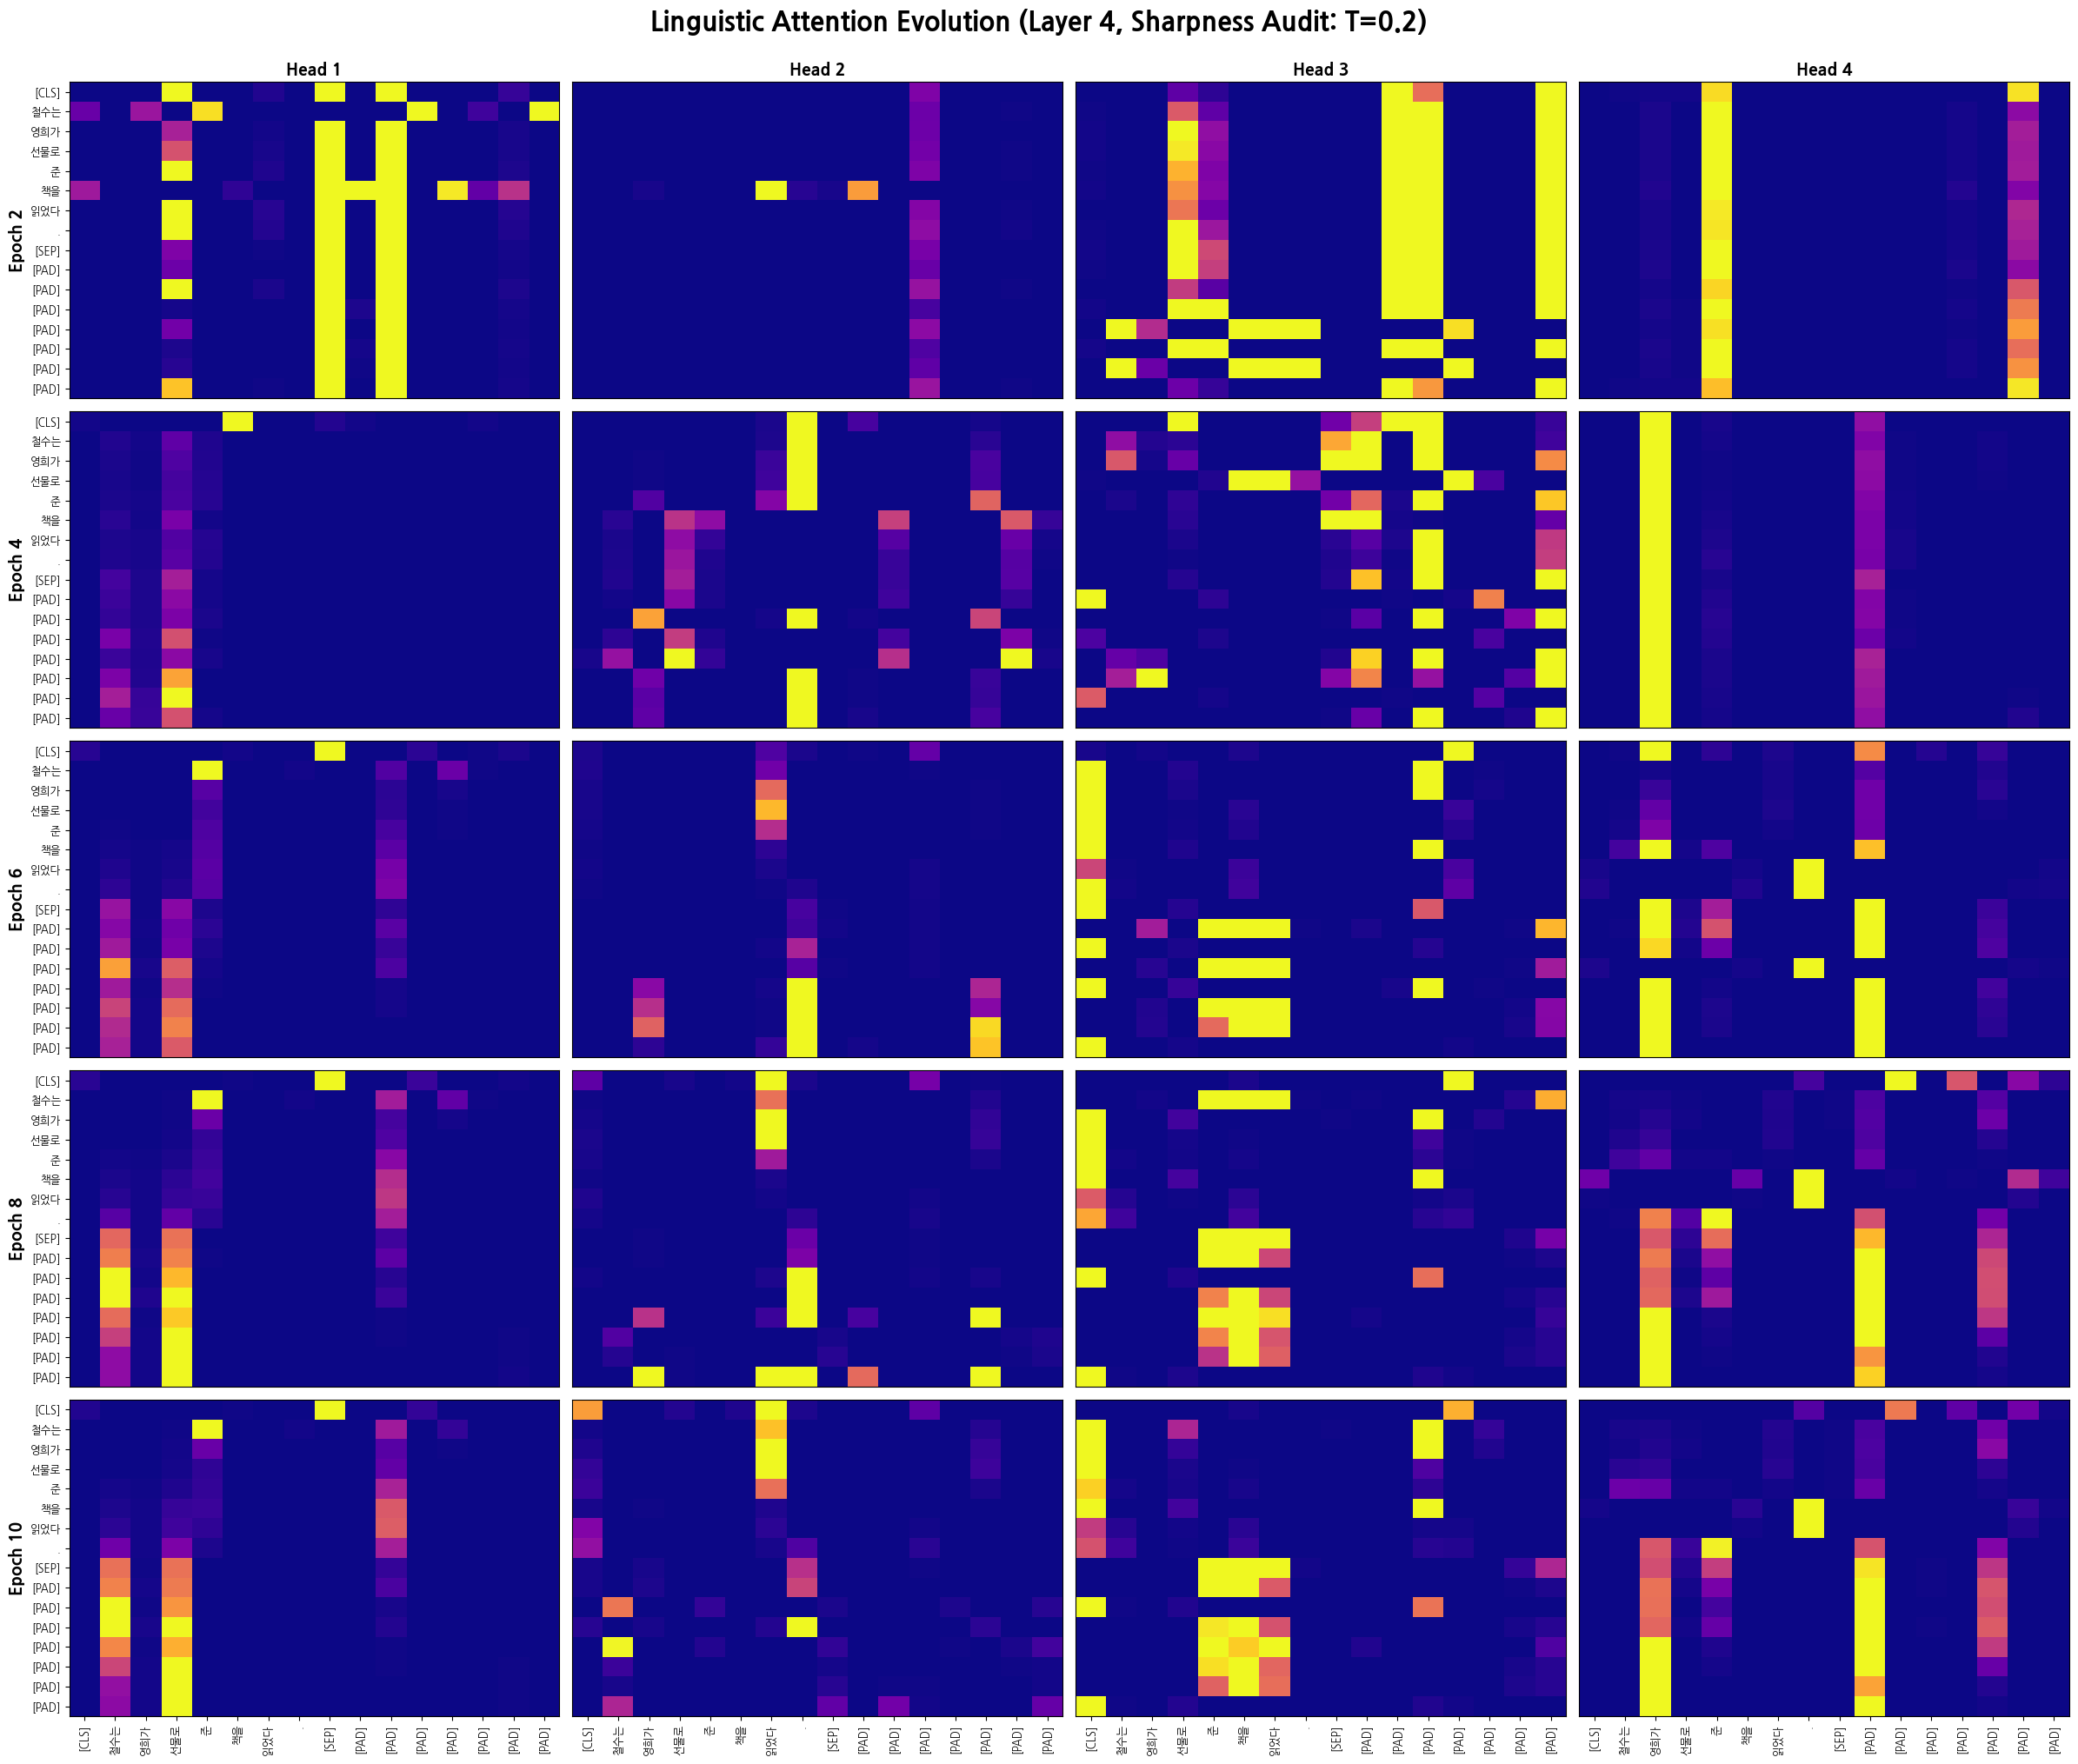

In [98]:
actual_labels = [
    "[CLS]", "철수는", "영희가", "선물로", "준", "책을", "읽었다", ".", "[SEP]", 
    "[PAD]", "[PAD]", "[PAD]", "[PAD]", "[PAD]", "[PAD]", "[PAD]"
]
audit_attention_evolution(actual_labels, target_epochs=[2, 4, 6, 8, 10])

#### 1. Simple Observations

* **Epoch-wise Developmental Trajectory:** 
  * The attention patterns exhibit rapid structural reorganization between Epoch 2 and Epoch 4, transitioning from stochastic noise to coherent linguistic mapping. 
  * From Epoch 4 through Epoch 10, the patterns undergo progressive refinement rather than fundamental shifts.
* **Non-Linear Head Evolution:** 
  * While most heads stabilize after Epoch 6, **Head 2** exhibits a distinct behavioral shift: the intensity of its attention weights gradually fades (lightens) as training progresses, suggesting the model is pruning redundant structural dependencies in favor of higher-level semantic processing.
* **Cross-Linguistic Structural Consistency:** 
  * Despite variations in input length and lexical content, the activation flow across both test sets remains nearly identical.
  * This demonstrates that the model has internalized universal syntactic rules independent of specific lexical content.
* **[CLS] Token Anchoring:** 
  * The `[CLS]` token consistently functions as a stable structural anchor, maintaining high attention weights across all epochs and layers.

#### 2. Diagnostic Insights

* **Syntactic Prior & MLM Bias:** 
  * The uniformity of patterns across different sentence structures reveals that the model has "conquered" syntax before semantics. 
  * Because MLM optimization is highly efficient when the model predicts grammatical markers, it directs the majority of the gradient toward mastering the "grammatical skeleton." 
    * Consequently, the attention mechanism is essentially locked into a standardized "structural filter."
* **The "Fading" of Head 2:** 
  * The observed fading intensity in Head 2 is a significant diagnostic indicator. 
  * As the model gains proficiency in identifying global sentence coherence (facilitated by the NSP objective), it reduces its reliance on the rigid, low-level structural dependencies initially captured by Head 2. 
    * This suggests a transition from purely syntactic parsing to more abstract, context-driven synthesis.
* **Structural Fixation:** 
  * The rapid stabilization from Epoch 4 onward indicates that the model has reached a state of **structural fixation**. 
  * The Encoder has successfully mapped the language's formal properties, but the persistent MLM bias means it treats the language as a structured prediction game rather than a dynamic semantic interaction.
* **Conclusion:** 
  * The attention maps confirm the model's successful transition from random parameter initialization to a stable, syntactically-aware encoder. 
  * However, the uniformity across different input lengths indicates that the model is constrained by its MLM-centric objective, prioritizing structural prediction efficiency over diverse contextual representation.

## Conclusion

#### A. Key Observations

* **Successful Structural Convergence:** 
  * After 10 epochs of training, the model has successfully internalized universal linguistic syntax. 
  * Through attention map analysis across layers, we demonstrated a standard language acquisition trajectory, progressing from syntactic analysis in early layers to semantic integration in deeper layers.
* **Hierarchical Evolution of Attention:** 
  * Attention pattern analysis revealed that early layers focus on syntactic information, such as relationships between adjacent words, while deeper layers integrate high-level context across the entire sentence—a characteristic typical of well-trained Transformer architectures.
* **Bottlenecks from Learning Imbalance:** 
  * Efficiency analysis indicates a "learning bias," where the Masked Language Modeling (MLM) task dominates 99.6% of the total gradient, severely restricting the model’s ability to improve contextual coherence via Next Sentence Prediction (NSP).
* **Structural Fixation:** 
  * The model has become excessively fixated on filters that extract the "grammatical skeleton" to maximize MLM prediction efficiency. 
  * Consequently, we observed a "structural fixation" phenomenon where attention maps display similar patterns regardless of input sentence length or content. 
    * This suggests that the model functions primarily as a statistical grammatical extractor rather than developing robust reasoning capabilities.

#### B. KPT Framework

**1. Keep**

* **Hierarchical Attention Diagnostic Pipeline:** 
  * Moving beyond reliance on accuracy metrics, the use of visualized multi-head attention maps to track internal information processing is an essential tool for identifying logical errors within the model.
* **Context-Invariant Structural Robustness:** 
  * The model's ability to maintain a stable grammatical skeleton regardless of input sentence length is a highly positive outcome in terms of its architectural design.

**2. Problem**

* **Learning Imbalance and Gradient Monopoly:** 
  * The overwhelming gradient share of the MLM task has biased the model toward structural parsing at the expense of semantic understanding.
* **Audit Failure (Reasoning Performance Degradation):** 
  * Qualitative Audit results show that the model not only fails in sentence-relationship reasoning via NSP but also exhibits "Mode Collapse" in the MLM task, where it repeatedly predicts high-frequency tokens. 
  * This indicates that the model is operating as a "statistical parrot," optimizing for easily predictable points rather than genuinely understanding context to determine correct answers.
* **Limited Head Expressivity:** 
  * With only 4 attention heads, the information compression rate is too high to granularly disentangle and represent multi-layered linguistic information (e.g., subject-predicate relationships, modifier structures). 
  * The difficulty in identifying the specific functional role of individual heads significantly hinders model interpretability.

**3. Try**

* **Loss Weighting Adjustment:** 
  * To compensate for the scale discrepancy between MLM Loss and NSP Loss, we plan to implement hyperparameter tuning that assigns specific weights to the NSP Loss, thereby reconfiguring the gradient flow to force the model to prioritize learning contextual coherence.
* **Attention Head Expansion and Structural Diversification:** 
  * We will expand the number of attention heads to 8 or more. This is intended to induce "specialization," where each head independently handles distinct linguistic elements or semantic features, creating an environment capable of learning complex reasoning relationships.
* **Data Augmentation and Context Enhancement:** 
  * We will acquire a more expansive and diverse range of domain-specific data to ensure the model evolves into a flexible language model that does not become fixated on specific grammatical patterns.
